In [47]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.colors as mcolors


# sns.set_theme(style="whitegrid")

sns.set_theme(style="whitegrid", font_scale=1.5, rc={
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.labelpad": 10,
    "axes.titlepad": 15,
    "legend.frameon": True,
    "legend.loc": "best",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.right": False,
    "axes.spines.top": False,
})

# enable the colorblind palette
sns.set_palette("colorblind")

In [48]:
# let get all the file that eng with xvg from the folder ../data/interim/PDB_to_MD
# path = '../data/interim/PDB_to_MD/'
path = '../data/interim/PDB_to_MD_14mM_NaCl/'  # Adjust as needed
# path = '../data/interim/PDB_to_MD_CA_5mM/'  # Adjust as needed

label_suffix = '14mM_NaCl' # 14mM_NaCl , 1M_NaCl , 25mM_Ca2

folders_level_1 = os.listdir(path)
# 

all_path_lists = []
for run_folder in folders_level_1:
    if os.path.isdir(os.path.join(path, run_folder)):
        all_path_lists.append(os.path.join(path, run_folder))
#         # get all the file that end with xvg
#         # files = glob(os.path.join('../data/interim/PDB_to_MD/', run_folder, '*.xvg'))

#         for run_folder_2 in os.listdir( os.path.join(path, run_folder)): 
#         # if os.path.isdir(os.path.join('../data/interim/PDB_to_MD/', run_folder)):
#             if os.path.isdir(os.path.join(path, run_folder, run_folder_2)):
#                 # print (run_folder_2, os.path.join(path, run_folder, run_folder_2))
#                 path_lists.append(os.path.join(path, run_folder, run_folder_2))



In [49]:
all_path_lists = [ x for x in all_path_lists if "NAC77_HAP21_Freq.13677" in x ]
# lets drop CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677
# all_path_lists = [ x for x in all_path_lists if "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677" not in x ]
all_path_lists = [ x for x in all_path_lists if "CBL8_HAP6_Freq.15315_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677" not in x ]
all_path_lists = [ x for x in all_path_lists if "CBL8_HAP6_Freq.3062_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677" not in x ]
all_path_lists = [ x for x in all_path_lists if "CBL8_HAP6_Freq.3062_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677" not in x ]
all_path_lists = [ x for x in all_path_lists if "CBL8_HAP7_Freq.15315_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677" not in x ]

In [50]:
all_path_lists

['../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP50_Freq.380_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677',
 '../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7

In [51]:
def plot_energy_analysis_for_haplotypes(plot_data_dict, group_label="CBL8_HAP7", output_dir="../data/interim/figures"):
    """
    Plots energy analysis for each column (except 'x') across all haplotypes in plot_data_dict.

    Args:
        plot_data_dict (dict): {filename: (df, legends)} for each haplotype.
        group_label (str): Label to use in plot titles and output filenames.
        output_dir (str): Directory to save the figures.
    """
    if not plot_data_dict:
        print("No data to plot.")
        return

    # Use the legends from the first entry
    first_key = next(iter(plot_data_dict))
    _, legends = plot_data_dict[first_key]
    columns = plot_data_dict[first_key][0].columns[1:]  # skip 'x'

    for column in columns:
        plt.figure(figsize=(20, 12))
        plt.title(f'Energy Analysis for {legends[column]} - {group_label}')
        plt.xlabel('Time (ps)')
        plt.ylabel('Energy (kJ/mol)')

        for filename, (df, legends) in plot_data_dict.items():
            sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.5)

        plt.legend(title='Haplotype', fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        # plt.savefig(os.path.join(output_dir, f'energy_analysis_{group_label}_{legends[column]}.png'), dpi=300)
        # plt.savefig(os.path.join(output_dir, f'energy_analysis_{group_label}_{legends[column]}_14mM_NaCl.png'), dpi=300)
        plt.savefig(os.path.join(output_dir, f'energy_analysis_{group_label}_{legends[column]}_{label_suffix}.png'), dpi=300)

        plt.close()

In [52]:
def xvg_to_df(path_to_energy_xvg):
    """
    Parse an .xvg file and return a DataFrame with the data and legends. This is assuming you are parsing the 
    Args:
        xvg_file (str): Path to the .xvg file.
    Returns:
        df (pd.DataFrame): DataFrame containing the data from the .xvg file.
        legends (dict): Dictionary containing the legends for each column.
    """
    # Parse the legends dynamically from the .xvg file
    legends = {}
    with open(path_to_energy_xvg, 'r') as file:
        for i, line in enumerate(file):
            if line.startswith("@ s"):
                # Extract the legend text after the "legend" keyword
                legend_text = line.split("legend", 1)[1].strip().strip('"')
                legend_index = line.split()[1]
                legends[f'{legend_index}'] = legend_text

    # Count the number of columns dynamically based on the number of "@ s" comments
    num_columns = len(legends)

    # Dynamically unpack the columns
    columns = ['x'] + [f's{i}' for i in range(num_columns)]
    data = np.loadtxt(path_to_energy_xvg , comments=["#", "@"], unpack=True)

    # Assign the unpacked data to dynamically created variables
    locals().update({col: data[i] for i, col in enumerate(columns)})

    # Create a DataFrame from the unpacked data
    df = pd.DataFrame(data.T, columns=columns) 

    return df, legends 



In [53]:
def plot_selected_lines(df, legends, columns, indices, title='GROMACS Energies', xlabel='Time (ps)', ylabel='kJ/mol'):
    """
    Plot selected lines from the DataFrame with legends.

    Args:
        df (pd.DataFrame): DataFrame containing the data to plot.
        legends (dict): Dictionary containing the legends for each column.
        columns (list): List of column names in the DataFrame.
        indices (list): List of indices of the columns to plot (excluding 'x').
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for idx in indices:
        col_name = columns[idx]
        sns.lineplot(x="x", y=col_name, data=df, label=legends[col_name], alpha=0.5)

    # Set the legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend", fontsize='small')
    plt.show()

In [54]:
def average_rmsf_from_xvg(file_list):
    """
    Given a list of .xvg files, load and average the RMSF (nanometers) data.
    Returns:
        atm_num (np.ndarray): Atom numbers (from the first file).
        avg_nanometers (np.ndarray): Averaged RMSF values.
    """
    avg_nanometers = None
    for i, file in enumerate(file_list):
        atm_num, nanometers = np.loadtxt(file, comments=["#", "@"], unpack=True)
        if i == 0:
            avg_nanometers = nanometers
        else:
            avg_nanometers += nanometers
    avg_nanometers = avg_nanometers / len(file_list)
    return atm_num, avg_nanometers

In [55]:
def find_all_rmsf_xvg_files(base_paths, filename="rmsf_selected_regions_CIPK17_NAC77.xvg"):
    """
    Find all rmsf_selected_regions_CIPK17_NAC77.xvg files in the given list of base paths.
    Returns a list of file paths.
    """
    all_files = []
    # print (f"Searching for files named '{filename}' in the following base paths:base_paths {base_paths}")
    for path in base_paths:
        # print(f"Checking base path: {path}")
        if not os.path.isdir(path):
            continue
        folders_level_1 = os.listdir(path)
        # print (f"Checking path: {path}")
        for run_folder in folders_level_1:
            full_folder_path = os.path.join(path, run_folder)
            # print(f"Checking folder: {full_folder_path}")
            if os.path.isdir(full_folder_path):
                files = glob(os.path.join(full_folder_path, filename))
                if files:
                    all_files.append(files[0])

    
    return all_files

In [56]:
def load_and_average_rmsf( path , file_name):
    """
    Load and average RMSF data from a list of file paths.
    
    Args:
        path_lists (list): List of file paths to .xvg files.
        
    Returns:
        atm_num (np.ndarray): Atom numbers.
        avg_nanometers (np.ndarray): Averaged RMSF values.
    """
    try :
        path_lists= find_all_rmsf_xvg_files( path , filename=file_name)
        atm_num, avg_nanometers = average_rmsf_from_xvg(path_lists)
        return atm_num, avg_nanometers
    except Exception as e:
        print(f"Error finding files in {path} with filename {file_name}: {e}")
        return None, None
   




In [57]:
# Plotting the RMSF results
def plot_rmsf_results(rmsf_results_dict, title):

    fig, axes = plt.subplots(3, 2, figsize=(16, 18), sharex=True, sharey=True)
    plt.suptitle(title, fontsize=16)
    axes = axes.flatten()

    for i, (path, (atm_num, avg_nanometers)) in enumerate(rmsf_results_dict.items()):
        ax = axes[i % 6]
        sns.lineplot(x=atm_num, y=avg_nanometers, label=os.path.basename(path), alpha=0.7, ax=ax)
        # ax.set_title(os.path.basename(path), fontsize=10)
        ax.set_xlabel('Residue number')
        ax.set_ylabel('RMS fluctuation (nm)')
        # ax.legend(fontsize='x-small')

    # Hide any unused subplots
    for j in range(len(rmsf_results_dict), 6):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [58]:
# Plotting the RMSF results
def plot_rmsf_results_solo(rmsf_results_dict, title):

    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=16)
    plt.xlabel('Residue number')
    plt.ylabel('RMS fluctuation (nm)')
    for i, (path, (atm_num, avg_nanometers)) in enumerate(rmsf_results_dict.items()):
        sns.lineplot(x=atm_num, y=avg_nanometers, label=os.path.basename(path), alpha=0.7)
    # plt.legend(fontsize='x-small')

    plt.legend(fontsize='x-small', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

In [59]:
# This is a line that controls the out out do not forget to change it 

# energy_list = find_all_rmsf_xvg_files(['../data/interim/PDB_to_MD/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/'], filename="energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg")

# energy_list = find_all_rmsf_xvg_files(['../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/'], filename="energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg")

energy_list = find_all_rmsf_xvg_files(['../data/interim/PDB_to_MD_CA_5mM/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/'], filename="energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg")


In [60]:
energy_list

['../data/interim/PDB_to_MD_CA_5mM/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/run2/energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg',
 '../data/interim/PDB_to_MD_CA_5mM/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/run3/energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg',
 '../data/interim/PDB_to_MD_CA_5mM/CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677/run1/energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg']

In [61]:
# we have a list of dataframes, I need the average of each column from the different dataframes
def average_energy_dataframes(file_list):
    """
    Load and average energy data from a list of .xvg files.
    
    Args:
        file_list (list): List of file paths to .xvg files.
        
    Returns:
        df_avg (pd.DataFrame): DataFrame containing the averaged energy data.
    """
    dfs = []
    for file in file_list:
        df, legends = xvg_to_df(file)
        dfs.append(df)

    # Concatenate all DataFrames and compute the mean
    df_concat = pd.concat(dfs, ignore_index=True)
    df_avg = df_concat.groupby('x').mean().reset_index()


    
    return df_avg ,legends 

In [62]:
def short_label(full_label):
    import re
    # # Extract gene and haplotype number
    # matches = re.findall(r'(CBL8|CIPK17|NAC77)_HAP(\d+)', full_label)
    # return ', '.join([f"{gene}:{hap}" for gene, hap in matches])

    # Extract gene and haplotype number and do not print NAC77
    matches = re.findall(r'(CBL8|CIPK17|NAC77)_HAP(\d+)', full_label)
    filtered_matches = [f"{gene}:hap{hap}" for gene, hap in matches if gene != "CBL8"]

    return ', '.join(filtered_matches)


In [63]:
energy_average_df , lengends = average_energy_dataframes(energy_list)

In [64]:
energy_average_df.head()

,x,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11
0,0.0,-12503.403971,-990.364136,-630.636597,-927.439535,-15481.469076,-1226.506836,-5653.384603,-377.407389,-269.978745,-223.114614,-4087.998454,-303.118296
1,10.0,-12428.537435,-1006.074463,-741.440613,-856.608195,-15305.691731,-1184.128703,-5689.618327,-364.118154,-249.260930,-225.672958,-4098.040609,-298.439382
2,20.0,-12521.502930,-999.177348,-709.871419,-875.528076,-15288.663411,-1204.688517,-5677.231282,-379.794037,-253.221497,-233.903442,-4051.079508,-286.639750
3,30.0,-12454.574219,-1018.420695,-692.991862,-868.670146,-15329.823242,-1192.571696,-5760.415202,-376.610636,-244.376495,-240.456950,-4075.693685,-291.896637
4,40.0,-12503.427409,-1009.602193,-706.497600,-869.026387,-15211.035807,-1208.116984,-5706.214681,-372.533498,-209.590200,-244.386571,-4020.302734,-282.309652


In [65]:
# Firts lets create a dictionary for the energy results 
# for each of the haplotypes in all_path_lists
# we will get the energy_average_df and labels 

energy_file_name = "energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg"
results_energy = {}
for idx , path in enumerate(all_path_lists):
   print(path)
   energy_list = find_all_rmsf_xvg_files([path], energy_file_name )
   energy_average_df , legends = average_energy_dataframes(energy_list)
   results_energy[path]=(energy_average_df , legends)
 

../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP50_Freq.380_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677
../data/interim/PDB_to_MD_14mM_NaCl/CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC

In [66]:
plot_data_dict = {}
for path in all_path_lists :
    energy_list = find_all_rmsf_xvg_files([path], filename="energy_analysis_CIPK17_CBL8_NAC77_interfaces.xvg")
    energy_average_df , legends = average_energy_dataframes(energy_list)
    # os.basename(path)
    filename = os.path.basename(path)
    plot_data_dict[filename] = (energy_average_df, legends)

In [67]:
plot_data_dict.keys()

dict_keys(['CBL8_HAP7_Freq.15315_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP50_Freq.380_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677', 'CBL8_HAP7_Freq.15315_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677', 'CBL8_HAP6_Freq.3062_C

In [68]:
#lets divide the plot_data_dict into two dictionaries, one for CBL8_HAP6 and one for CBL8_HAP7
cbl8_hap6_plot_data = {k: v for k, v in plot_data_dict.items() if 'CBL8_HAP6' in k}
cbl8_hap7_plot_data = {k: v for k, v in plot_data_dict.items() if 'CBL8_HAP7' in k}


In [69]:

# Now we can plot the energy analysis for CBL8_HAP6 and CBL8_HAP7
# for column in cbl8_hap6_plot_data[next(iter(cbl8_hap6_plot_data))][0].columns[1:]:
#     plt.figure(figsize=(20, 12))
#     plt.title(f'Energy Analysis for {legends[column]} - CBL8_HAP6')
#     plt.xlabel('Time (ps)')
#     plt.ylabel('Energy (kJ/mol)')
    
#     for filename, (df, legends) in cbl8_hap6_plot_data.items():
#         sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.5)
    
#     plt.legend(title='Haplotype', fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
#     plt.tight_layout()
#     plt.savefig(f'../data/interim/figures/energy_analysis_CBL8_HAP6_{legends[column]}.png', dpi=300)
#     # plt.show()
# for column in cbl8_hap7_plot_data[next(iter(cbl8_hap7_plot_data))][0].columns[1:]:
#     plt.figure(figsize=(20, 12))
#     plt.title(f'Energy Analysis for {legends[column]} - CBL8_HAP7')
#     plt.xlabel('Time (ps)')
#     plt.ylabel('Energy (kJ/mol)')
    
#     for filename, (df, legends) in cbl8_hap7_plot_data.items():
#         sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.5)
    
#     plt.legend(title='Haplotype', fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
#     plt.tight_layout()
#     plt.savefig(f'../data/interim/figures/energy_analysis_CBL8_HAP7_{legends[column]}.png', dpi=300)
#     # plt.show()

CBL8_HAP6_Freq.3062_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP50_Freq.380_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677
9 CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677
8 CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677
4 CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677
CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677
CBL8_HAP7_Freq.15315_CIPK17_HAP47_Freq.204_NAC77_HAP21_Freq.13677
CBL8_HAP7_Freq.15315_CIPK17_HAP48_Freq.237_NAC77_HAP21_Freq.13677
CBL8_HAP7_Freq.15315_CIPK17_HAP49_Freq.344_NAC77_HAP21_Freq.13677
CBL8_HAP7_Freq.15315_CIPK17_HAP50_Freq.380_NAC77_HAP21_Freq.13677
7 CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677
6 CBL8_HAP7_Freq.15315_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677
5 CBL8_HAP7_Freq.15315_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677
3 CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677
2 CBL8_HAP7_Freq.15315_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677
1 CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677

In [70]:
KEYS_for_plot_hap7 = [
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677"]

KEYS_for_plot_hap6 = [
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677",
                    "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677"]

# select the keys for the plot from cbl8_hap6_plot_data and cbl8_hap7_plot_data
# KEYS_for_plot_hap6 = list(cbl8_hap6_plot_data.keys())
# KEYS_for_plot_hap7 = list(cbl8_hap7_plot_data.keys())
# lets create a dictionary for the plot data
plot_data_dict_hap6 = {}
for key in KEYS_for_plot_hap6:
    if key in plot_data_dict:
        plot_data_dict_hap6[key] = plot_data_dict[key]
plot_data_dict_hap7 = {}
for key in KEYS_for_plot_hap7:
    if key in plot_data_dict:
        plot_data_dict_hap7[key] = plot_data_dict[key]


In [71]:

# Define your color palette, ensuring the specified key is always red
custom_colors = sns.color_palette("colorblind", n_colors=len(plot_data_dict_hap6))
color_dict = {k: c for k, c in zip(plot_data_dict_hap6.keys(), custom_colors)}
# Add the plot_data_dict_hap7 to the color_dict
for k in plot_data_dict_hap7.keys():
    if k not in color_dict:
        color_dict[k] = custom_colors[len(color_dict) % len(custom_colors)]

# Override for the special key
special_key = "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677"
color_dict[special_key] = "red"


EMPH_KEYS = {
    "CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
    "CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
}
# Exchange the colors to make with CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677 and the EMPH_KEYS
temp = color_dict["CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677"]
original_color = color_dict["CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677"]

color_dict["CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677"] = temp
color_dict["CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677"] = original_color


temp = color_dict["CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677"]
original_color = color_dict["CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677"]

color_dict["CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677"] = temp
color_dict["CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677"] = original_color


In [72]:
color_dict

{'CBL8_HAP6_Freq.3062_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677': (0.8352941176470589,
  0.3686274509803922,
  0.0),
 'CBL8_HAP6_Freq.3062_CIPK17_HAP52_Freq.947_NAC77_HAP21_Freq.13677': (0.8705882352941177,
  0.5607843137254902,
  0.0196078431372549),
 'CBL8_HAP6_Freq.3062_CIPK17_HAP53_Freq.1974_NAC77_HAP21_Freq.13677': (0.00784313725490196,
  0.6196078431372549,
  0.45098039215686275),
 'CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677': (0.00392156862745098,
  0.45098039215686275,
  0.6980392156862745),
 'CBL8_HAP6_Freq.3062_CIPK17_HAP55_Freq.4952_NAC77_HAP21_Freq.13677': (0.8,
  0.47058823529411764,
  0.7372549019607844),
 'CBL8_HAP6_Freq.3062_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677': (0.792156862745098,
  0.5686274509803921,
  0.3803921568627451),
 'CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677': 'red',
 'CBL8_HAP7_Freq.15315_CIPK17_HAP51_Freq.492_NAC77_HAP21_Freq.13677': (0.8352941176470589,
  0.3686274509803922,
  0.0),
 'CBL8_HAP7_F

In [73]:
EMPH_KEYS = {
    "CBL8_HAP6_Freq.3062_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
    "CBL8_HAP7_Freq.15315_CIPK17_HAP54_Freq.2103_NAC77_HAP21_Freq.13677",
    "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677"
}

In [74]:

# for column in plot_data_dict_hap6[next(iter(plot_data_dict_hap6))][0].columns[1:]:
#     plt.figure(figsize=(20, 12))
#     plt.title(f'Energy Analysis for {legends[column]} - Interfaces', fontsize=22)
#     plt.xlabel('Time (ps)', fontsize=22)
#     plt.ylabel('Energy (kJ/mol)',  fontsize=22)
    
#     for filename, (df, legends) in plot_data_dict_hap6.items():
#         color = color_dict.get(filename, None)
#         sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.5, color=color)
    
#     plt.legend(title='Haplotype', fontsize='large', loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
#     plt.xticks(fontsize=20)
#     plt.yticks(fontsize=20)
#     plt.tight_layout()
#     plt.savefig(f'../data/interim/figures/energy_analysis_interfaces_group_hap6_{legends[column]}.png', dpi=300)
#     plt.close()


In [75]:
# Use the rc parameters and style set in the first cell for Nature-style figures
for column in plot_data_dict_hap6[next(iter(plot_data_dict_hap6))][0].columns[1:]:
    plt.figure(figsize=(9, 7))  # Adjust as needed for balance
    # plt.title(f'{legends[column]}', fontsize=20, pad=15)
    plt.xlabel('Time (ps)', fontsize=18, labelpad=10)
    plt.ylabel('Energy (kJ/mol)', fontsize=18, labelpad=10)
    
    # for filename, (df, legends) in plot_data_dict_hap6.items():
    #     color = color_dict.get(filename, None)
    #     # sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.8, linewidth=2, color=color)
    #     short = short_label(filename)
    #     sns.lineplot(x='x', y=column, data=df, label=short, alpha=0.8, linewidth=2, color=color)
    
    for filename, (df, legends) in plot_data_dict_hap6.items():
        is_emph = filename in EMPH_KEYS
        color = color_dict.get(filename, None)
        # sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.8, linewidth=2, color=color)
        short = short_label(filename)
        if is_emph:
            sns.lineplot(x='x', y=column, data=df, label=short, alpha=0.8, linewidth=2, color=color, zorder=10)
        else:
            sns.lineplot(x='x', y=column, data=df, label=short, alpha=0.4, linewidth=1, color=color, zorder=2)


    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.tight_layout(rect=[0, 0.15, 1, 1])  # Leave space at the bottom for the legend
    # plt.legend(
    #     title='Haplotype',
    #     fontsize=12,
    #     title_fontsize=14,
    #     # loc='lower center',
    #     # bbox_to_anchor=(0.5, -0.25),
    #     loc='upper right',
    #     bbox_to_anchor=(1.0, 1.0),
    #     ncol=1,
    #     frameon=True
    # )
    plt.legend(
        title='Haplotype',
        fontsize=12,
        title_fontsize=14,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        frameon=True
    )
    plt.savefig(
        # f'../data/interim/figures/energy_analysis_interfaces_group_hap6_{legends[column].replace(":", "_")}_nature.svg',
        # f'../data/interim/figures/energy_analysis_interfaces_group_hap6_{legends[column].replace(":", "_")}_nature_14mM_NaCl.svg',
        f'../data/interim/figures/energy_analysis_interfaces_group_hap6_{legends[column].replace(":", "_")}_nature_{label_suffix}.svg',

        dpi=300,
        bbox_inches='tight',
        transparent=True
    )
    plt.close()


In [76]:
# # Define your color palette, ensuring the specified key is always red
# custom_colors = sns.color_palette("colorblind", n_colors=len(plot_data_dict_hap7))
# color_dict = {k: c for k, c in zip(plot_data_dict_hap7.keys(), custom_colors)}
# # Override for the special key
# special_key = "CBL8_HAP7_Freq.15315_CIPK17_HAP56_Freq.6124_NAC77_HAP21_Freq.13677"
# color_dict[special_key] = "red"

In [77]:
# for column in plot_data_dict_hap7[next(iter(plot_data_dict_hap7))][0].columns[1:]:
#     plt.figure(figsize=(20, 12))
#     plt.title(f'Energy Analysis for {legends[column]} - Interfaces', fontsize=22)
#     plt.xlabel('Time (ps)', fontsize=22)
#     plt.ylabel('Energy (kJ/mol)', fontsize=22)
    
#     for filename, (df, legends) in plot_data_dict_hap7.items():
#         color = color_dict.get(filename, None)
#         sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.5, color=color)
    
#     plt.legend(title='Haplotype', fontsize='large', loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
#     plt.xticks(fontsize=20)
#     plt.yticks(fontsize=20)
#     plt.tight_layout()
#     plt.savefig(f'../data/interim/figures/energy_analysis_interfaces_group_hap7_{legends[column]}.png', dpi=300)
#     plt.close()

In [78]:
# Use the rc parameters and style set in the first cell for Nature-style figures
# this is plotting only 6 columns
for column in plot_data_dict_hap7[next(iter(plot_data_dict_hap7))][0].columns[1:]:
    plt.figure(figsize=(9, 7))  # Adjust as needed for balance
    # plt.title(f'{legends[column]}', fontsize=20, pad=15)
    plt.xlabel('Time (ps)', fontsize=18, labelpad=10)
    plt.ylabel('Energy (kJ/mol)', fontsize=18, labelpad=10)
    
    for filename, (df, legends) in plot_data_dict_hap7.items():
        is_emph = filename in EMPH_KEYS
        color = color_dict.get(filename, None)
        # sns.lineplot(x='x', y=column, data=df, label=filename, alpha=0.8, linewidth=2, color=color)
        short = short_label(filename)
        if is_emph:
            sns.lineplot(x='x', y=column, data=df, label=short, alpha=0.8, linewidth=2, color=color, zorder=10)
        else:
            sns.lineplot(x='x', y=column, data=df, label=short, alpha=0.4, linewidth=1, color=color, zorder=2)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space at the right for the legend
    plt.legend(
        title='Haplotype',
        fontsize=12,
        title_fontsize=14,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        frameon=True
    )
    plt.savefig(
        # f'../data/interim/figures/energy_analysis_interfaces_group_hap7_{legends[column].replace(":", "_")}_nature.svg',
        # f'../data/interim/figures/energy_analysis_interfaces_group_hap7_{legends[column].replace(":", "_")}_nature_14mM_NaCl.svg',
        f'../data/interim/figures/energy_analysis_interfaces_group_hap7_{legends[column].replace(":", "_")}_nature_{label_suffix}.svg',

        dpi=300,
        bbox_inches='tight',
        transparent=True
    )
    plt.close()

In [79]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [80]:
def permutation_test_p_lower(a, b, nperm=5000, seed=0):
    """Paired sign-flip permutation test for mean(a-b) one-sided (a < b)."""
    diff = a - b
    diff = diff[~np.isnan(diff)]
    if diff.size == 0:
        return np.nan
    rng = np.random.default_rng(seed)
    obs = diff.mean()
    perms = []
    for _ in range(nperm):
        signs = rng.choice([1, -1], size=diff.size)
        perms.append((signs * diff).mean())
    perms = np.array(perms)
    # one-sided lower: proportion of permuted means <= observed
    p_lower = (np.sum(perms <= obs) + 1) / (nperm + 1)
    return obs, p_lower

def paired_cohen_d(a, b):
    diff = a - b
    diff = diff[~np.isnan(diff)]
    if diff.size <= 1:
        return np.nan
    return np.mean(diff) / (np.std(diff, ddof=1))


In [81]:
# Settings
ref_key = special_key  # uses notebook variable
nperm = 5000
out_dir = "../data/interim/results_statistics"
os.makedirs(out_dir, exist_ok=True)
# out_csv = os.path.join(out_dir, "energy_compare_hap6_vs_special_key_hap7.csv") # this is 1M NaCl
# out_csv = os.path.join(out_dir, "energy_compare_hap6_vs_special_key_hap7_14mM_NaCl.csv") # this is 14mM NaCl
out_csv = os.path.join(out_dir, f"energy_compare_hap6_vs_special_key_hap7_{label_suffix}.csv") # this is 5mM Ca2


if ref_key not in plot_data_dict_hap6:
    raise KeyError(f"Reference key not found in plot_data_dict_hap6: {ref_key}")

ref_df, ref_legends = plot_data_dict_hap6[ref_key]
x_col = "x"

results = []

In [82]:
# iterate over columns (exclude x)
cols = [c for c in ref_df.columns if c != x_col]
for col in cols:
    # compare each series (row per haplotype) against reference for this column
    for key, (df, legends) in plot_data_dict_hap6.items():
        if key == ref_key:
            continue
        # align on 'x' if present
        if x_col in df.columns and x_col in ref_df.columns:
            merged = pd.merge(ref_df[[x_col, col]].rename(columns={col: "ref"}),
                              df[[x_col, col]].rename(columns={col: "series"}),
                              on=x_col, how="inner")
            a = merged["series"].values
            b = merged["ref"].values
        else:
            # fallback: align by index if same length
            if len(df) == len(ref_df):
                a = df[col].values
                b = ref_df[col].values
            else:
                # cannot align
                raise ValueError(f"Cannot align series {key} with reference for column {col}")

        # paired t-test (two-sided -> convert to one-sided lower)
        t_stat, p_two = stats.ttest_rel(a, b, nan_policy="omit")
        # convert to one-sided 'lower' (series < ref)
        if np.isnan(t_stat) or np.isnan(p_two):
            p_one_lower = np.nan
        else:
            if t_stat < 0:
                p_one_lower = p_two / 2.0
            else:
                p_one_lower = 1.0 - (p_two / 2.0)

        mean_diff = np.nanmean(a - b)  # series - reference
        cohen_d = paired_cohen_d(a, b)

        # permutation test (paired sign-flip) one-sided lower
        try:
            obs_mean, p_perm_lower = permutation_test_p_lower(a, b, nperm=nperm)
        except Exception:
            obs_mean, p_perm_lower = np.nan, np.nan

        results.append({
            "column": col,
            "series_key": key,
            "ref_key": ref_key,
            "mean_diff_series_minus_ref": mean_diff,
            "t_stat": t_stat,
            "p_t_one_sided_lower": p_one_lower,
            "perm_obs_mean": obs_mean,
            "p_perm_one_sided_lower": p_perm_lower,
            "cohen_d_paired": cohen_d
        })

res_df = pd.DataFrame(results)

In [83]:
# FDR correction performed separately for the t-test and permutation p-values
for pcol, adjcol, rejcol in [
    ("p_t_one_sided_lower", "p_t_one_sided_lower_fdr", "reject_t_fdr"),
    ("p_perm_one_sided_lower", "p_perm_one_sided_lower_fdr", "reject_perm_fdr")
]:
    mask = ~res_df[pcol].isna()
    if mask.any():
        rej, p_adj, _, _ = multipletests(res_df.loc[mask, pcol].values, alpha=0.05, method="fdr_bh")
        res_df.loc[mask, adjcol] = p_adj
        res_df.loc[mask, rejcol] = rej
    else:
        res_df[adjcol] = np.nan
        res_df[rejcol] = False

# Flag series that are significantly lower by both tests (optional)
res_df["lower_by_both"] = (res_df["reject_t_fdr"] == True) & (res_df["reject_perm_fdr"] == True) & (res_df["mean_diff_series_minus_ref"] < 0)

# save CSV
res_df.to_csv(out_csv, index=False)
print(f"Results written to {out_csv}")
# quick summary
summary = res_df.groupby("column").apply(lambda g: g[g["lower_by_both"]].shape[0])
print("Number of series significantly lower than reference (both tests) per column:")
print(summary)

Results written to ../data/interim/results_statistics/energy_compare_hap6_vs_special_key_hap7_14mM_NaCl.csv
Number of series significantly lower than reference (both tests) per column:
column
s0     2
s1     0
s10    0
s11    3
s2     5
s3     5
s4     1
s5     2
s6     2
s7     3
s8     0
s9     2
dtype: int64


In [84]:
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# Build combined legend map from all hap6 entries (fall back if ref_legends missing keys)
combined_legends = {}
for k, (df, legends) in plot_data_dict_hap6.items():
    # legends keys are typically 's0','s1',...; store as-is
    for lk, lv in legends.items():
        combined_legends[str(lk)] = lv

def resolve_label(col_key):
    col_key = str(col_key)
    # direct match
    if col_key in combined_legends:
        return combined_legends[col_key]
    # try with/without leading 's'
    if col_key.startswith('s') and col_key[1:] in combined_legends:
        return combined_legends[col_key[1:]]
    if not col_key.startswith('s') and ('s' + col_key) in combined_legends:
        return combined_legends['s' + col_key]
    # fallback: return original key
    return col_key

# keep raw column key for traceability and replace 'column' with label
res_df['column_raw'] = res_df['column']
res_df['column'] = res_df['column_raw'].apply(resolve_label)

# also update any pivot/plots that rely on column names if needed (not done here)
# re-save CSV (overwrite)
res_df.to_csv(out_csv, index=False)
print(f"Saved results with human labels to {out_csv}")
# show mapping for quick check
unique_keys = res_df['column_raw'].unique()
print("Mapping (raw -> label):")
for k in unique_keys:
    print(f"  {k} -> {resolve_label(k)}")

Saved results with human labels to ../data/interim/results_statistics/energy_compare_hap6_vs_special_key_hap7_14mM_NaCl.csv
Mapping (raw -> label):
  s0 -> Coul-SR:interface_CIPK17_to_CBL8-interface_CIPK17_to_CBL8
  s1 -> LJ-SR:interface_CIPK17_to_CBL8-interface_CIPK17_to_CBL8
  s2 -> Coul-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17
  s3 -> LJ-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17
  s4 -> Coul-SR:interface_CBL8_to_CIPK17-interface_CBL8_to_CIPK17
  s5 -> LJ-SR:interface_CBL8_to_CIPK17-interface_CBL8_to_CIPK17
  s6 -> Coul-SR:interface_NAC77_to_CIPK17-interface_NAC77_to_CIPK17
  s7 -> LJ-SR:interface_NAC77_to_CIPK17-interface_NAC77_to_CIPK17
  s8 -> Coul-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77
  s9 -> LJ-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77
  s10 -> Coul-SR:interface_CIPK17_to_NAC77-interface_CIPK17_to_NAC77
  s11 -> LJ-SR:interface_CIPK17_to_NAC77-interface_CIPK17_to_NAC77


/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/3563269094.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


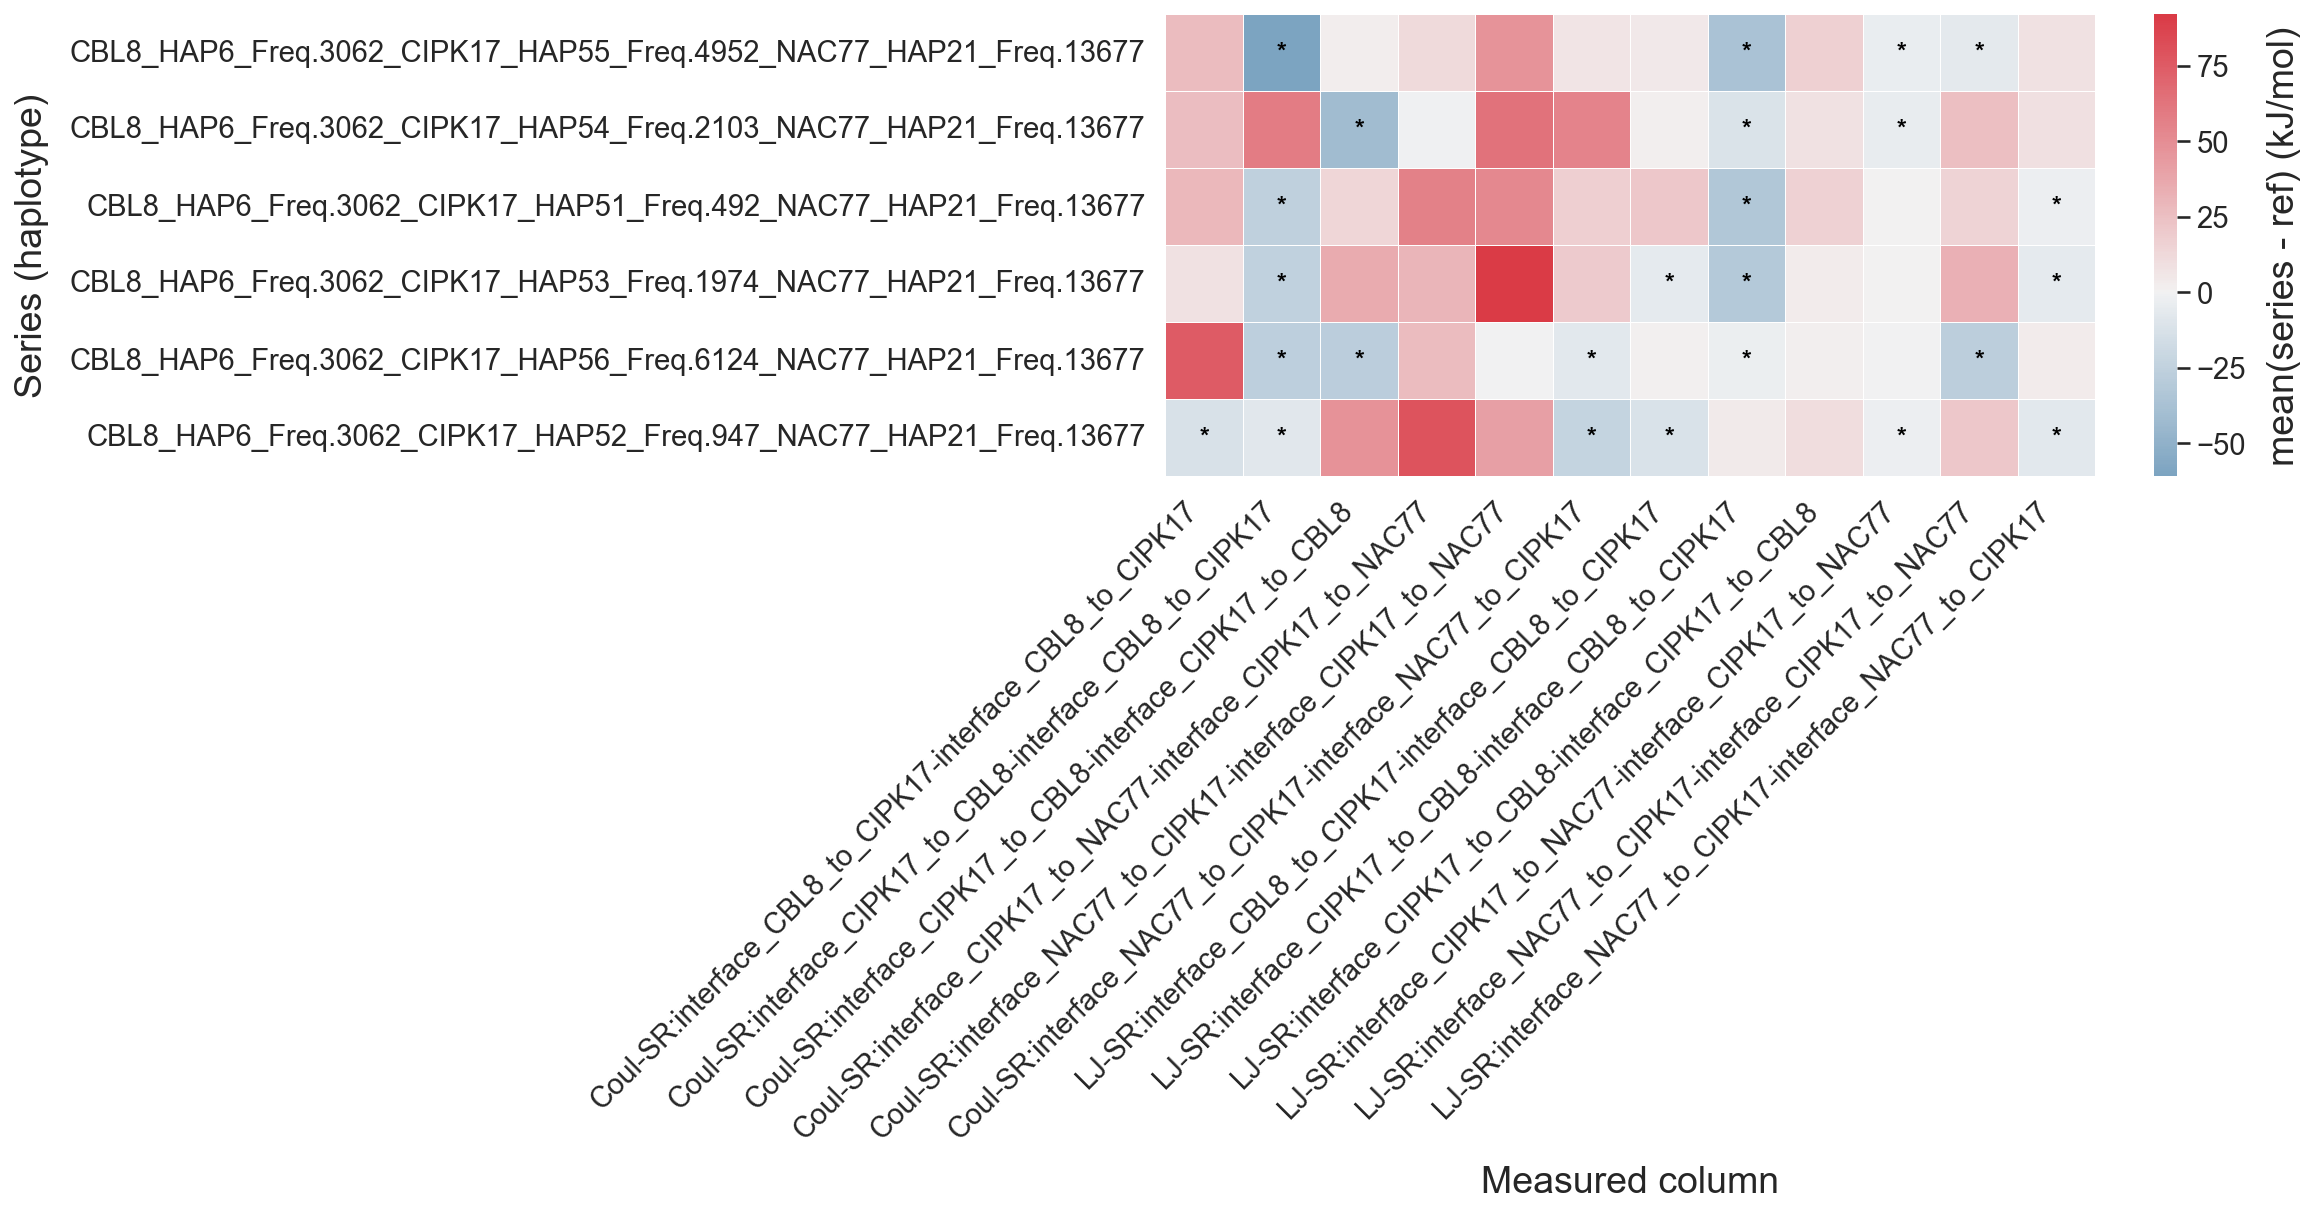

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/3563269094.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


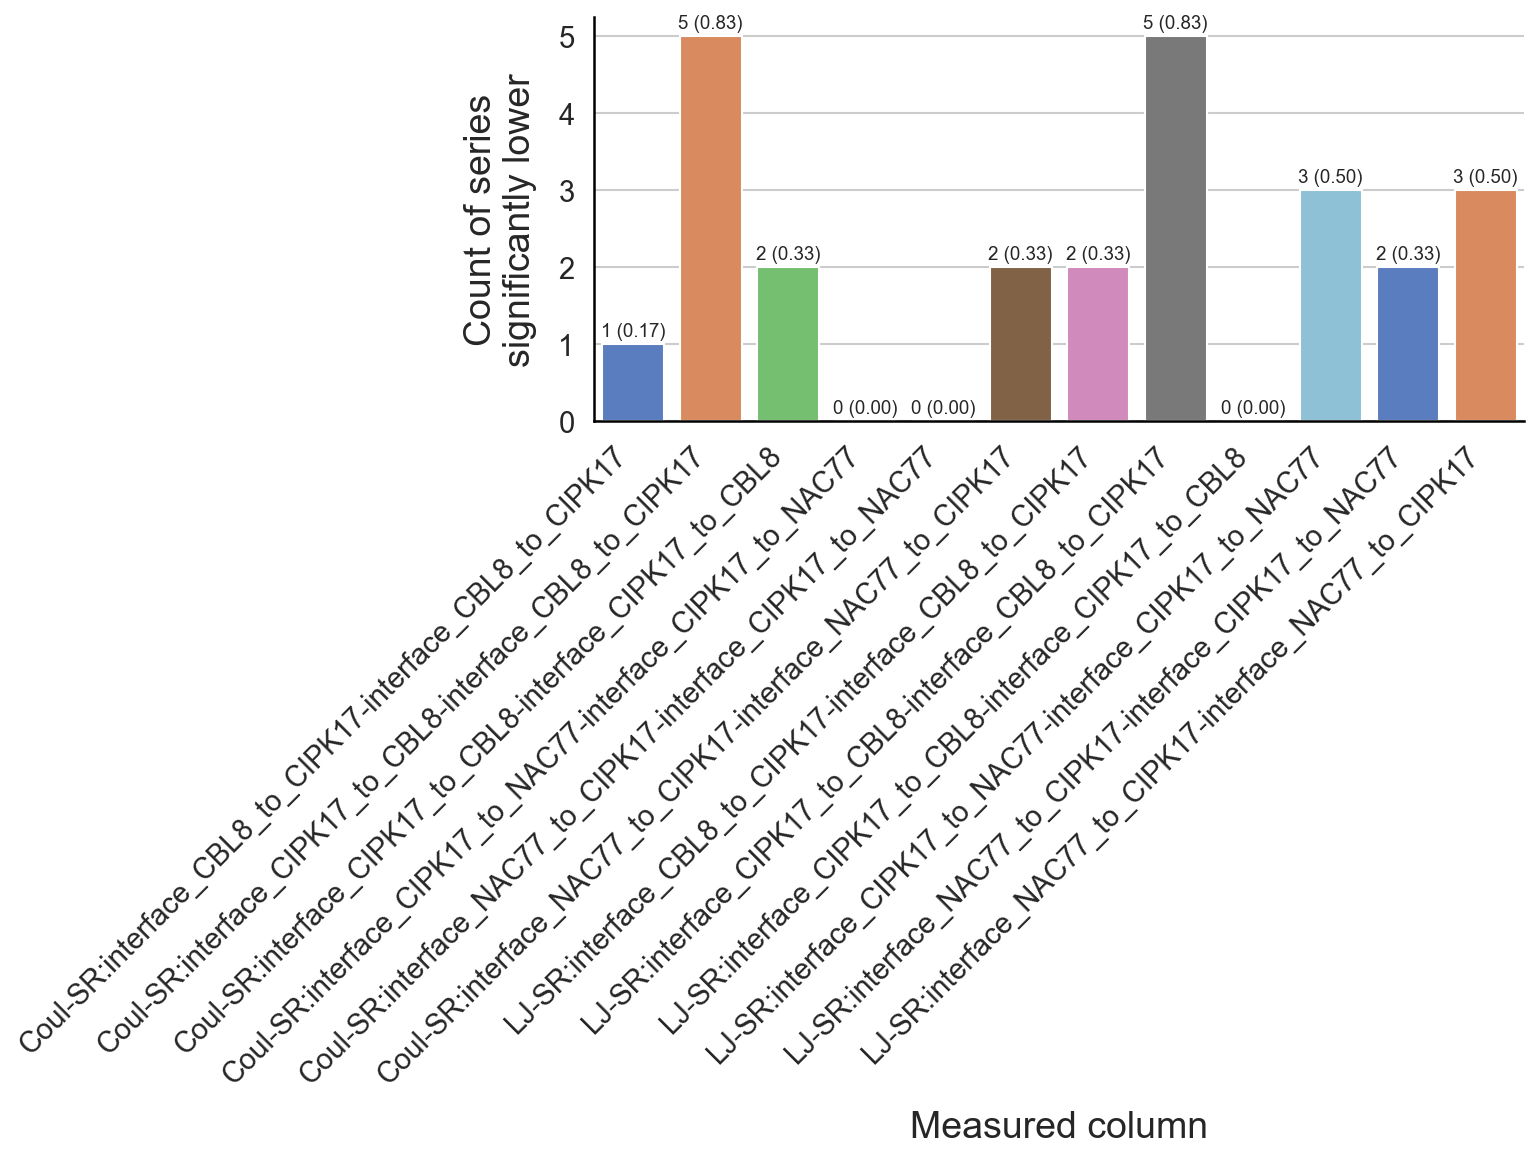

Saved: ../data/interim/results_statistics/summary_heatmap_mean_diff_with_significance_hap6_14mM_NaCl.svg
       ../data/interim/results_statistics/summary_counts_lower_than_ref_hap6_14mM_NaCl.svg


In [85]:
# requires res_df from previous cell
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# pivot mean differences and significance mask
pivot_mean = res_df.pivot(index='series_key', columns='column', values='mean_diff_series_minus_ref')
pivot_sig = res_df.pivot(index='series_key', columns='column', values='lower_by_both').fillna(False)

# sort rows for nicer display (optional: by sum of negative diffs)
row_order = (pivot_mean.fillna(0).min(axis=1)).sort_values().index
pivot_mean = pivot_mean.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]

os.makedirs(out_dir, exist_ok=True)
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_with_significance_hap6.svg")
figpath = os.path.join(out_dir, f"summary_heatmap_mean_diff_with_significance_hap6_{label_suffix}.svg")


plt.figure(figsize=(10, max(4, 0.3 * pivot_mean.shape[0])))
cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue <-> red, center=0
ax = sns.heatmap(pivot_mean, cmap=cmap, center=0, annot=False, fmt=".2f",
                 cbar_kws={'label': 'mean(series - ref) (kJ/mol)'}, linewidths=0.3)

# overlay significance stars
for (i, j), val in np.ndenumerate(pivot_sig.values):
    if val:
        ax.text(j + 0.5, i + 0.5, "*", ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax.set_xlabel("Measured column")
ax.set_ylabel("Series (haplotype)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figpath, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Small summary barplot: number (and fraction) of series significantly lower per column
summary = res_df[res_df['lower_by_both']].groupby('column').size().reindex(pivot_mean.columns, fill_value=0)
total_per_col = res_df.groupby('column').size().reindex(pivot_mean.columns, fill_value=0)
frac = summary / total_per_col

fig2, ax2 = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=summary.index, y=summary.values, palette='muted', ax=ax2)
for i, (cnt, f) in enumerate(zip(summary.values, frac.values)):
    ax2.text(i, cnt + 0.05, f"{cnt} ({f:.2f})", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel("Count of series\nsignificantly lower")
ax2.set_xlabel("Measured column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_hap6.svg") # this is 1M NaCl
# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_hap6_14mM_NaCl.svg") # this is 14mM NaCl
outbar = os.path.join(out_dir, f"summary_counts_lower_than_ref_hap6_{label_suffix}.svg") # this is 5mM Ca2

plt.savefig(outbar, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved: {figpath}\n       {outbar}")

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/389603447.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


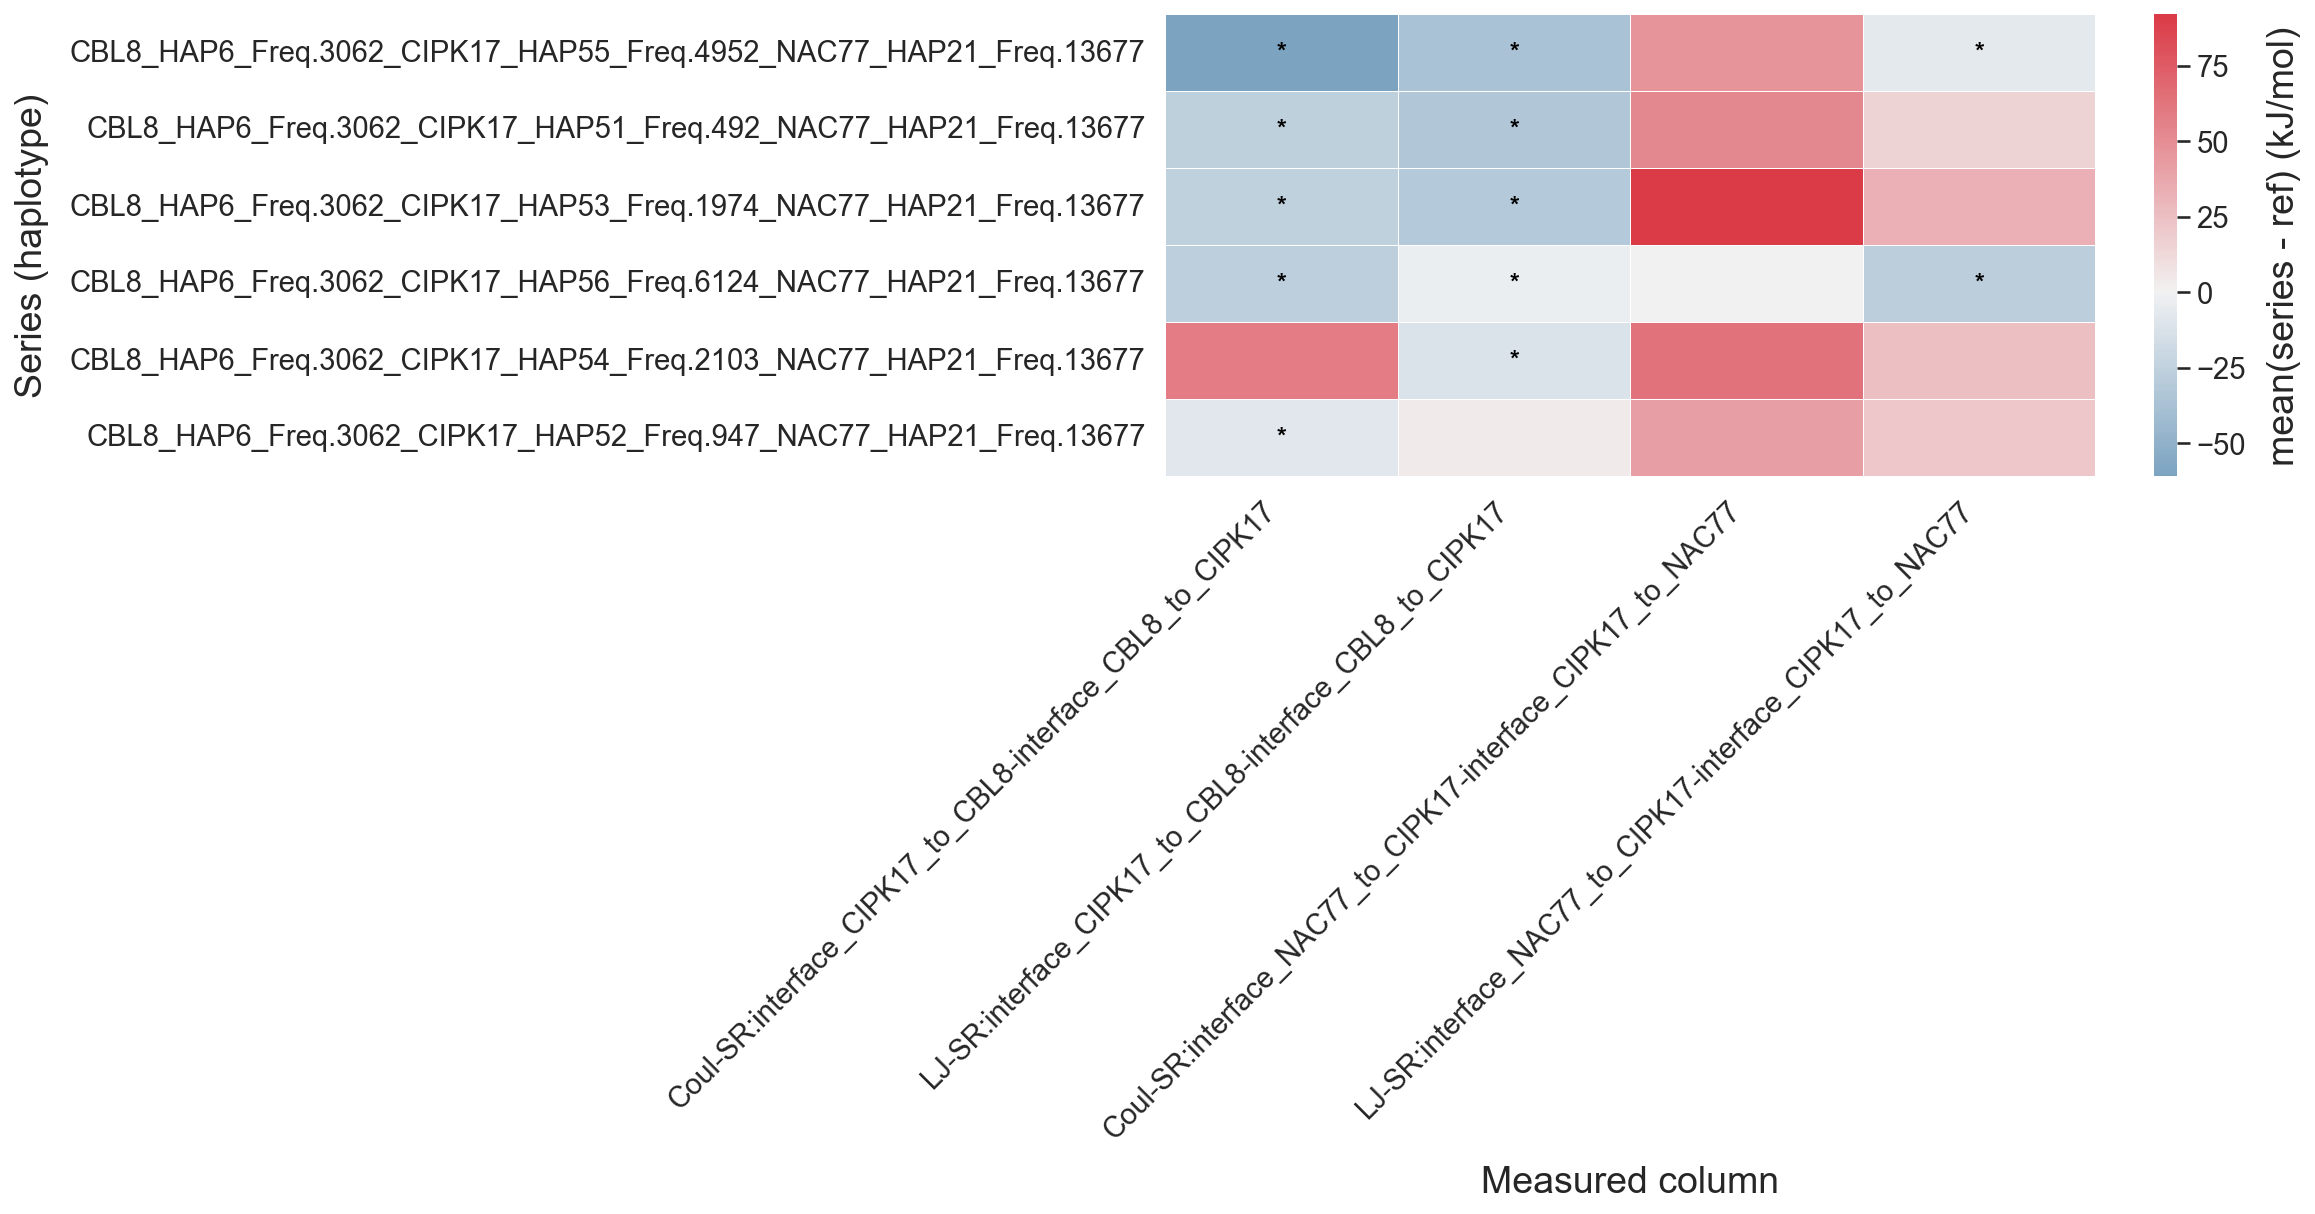

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/389603447.py:73: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


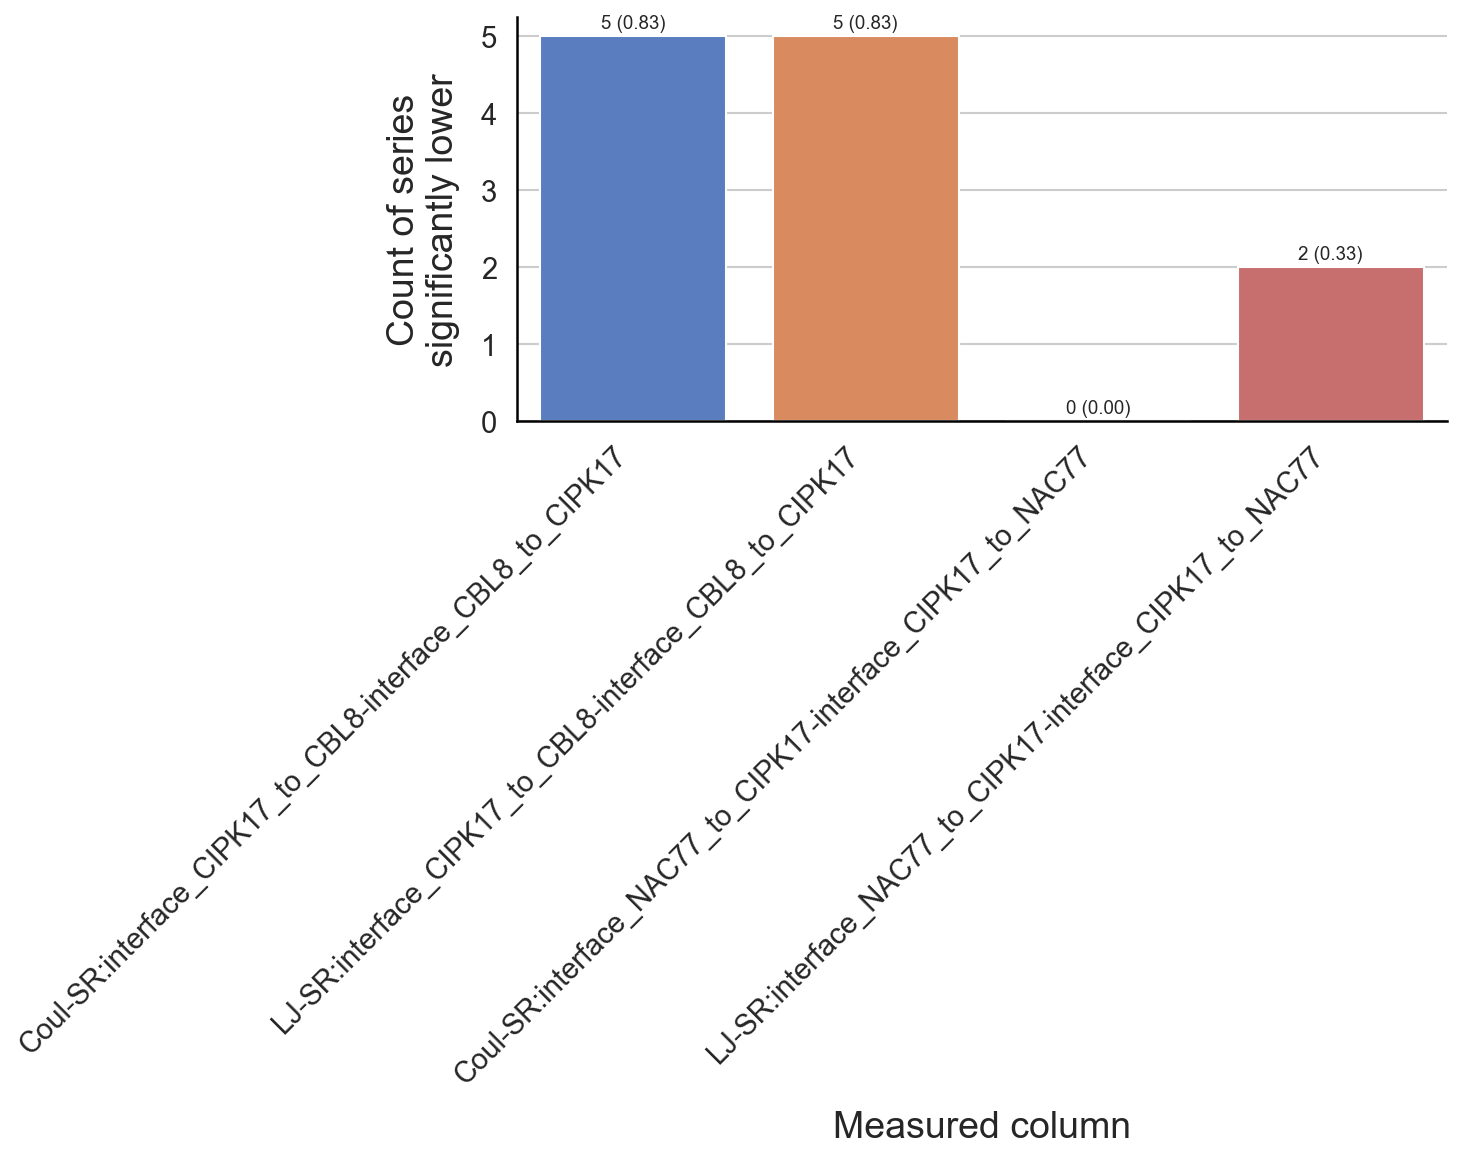

Saved: ../data/interim/results_statistics/summary_heatmap_mean_diff_interfaces_filtered_hap6_14mM_NaCl.svg
       ../data/interim/results_statistics/summary_counts_lower_than_ref_interfaces_filtered_hap6_14mM_NaCl.svg


In [86]:
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# only plot these four interface labels (order preserved)
ALLOWED = [
    "Coul-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17",
    "LJ-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17",
    "Coul-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77",
    "LJ-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77",
]

present = [c for c in ALLOWED if c in set(res_df['column'])]
if not present:
    print("None of the requested interface columns found in res_df['column'].")
    print("Available columns:", sorted(set(res_df['column'])))
    raise RuntimeError("No matching interface columns to plot.")

# filter to only the allowed interface rows
res_sub = res_df[res_df['column'].isin(present)].copy()

# pivot mean differences and significance mask (only selected columns)
pivot_mean = res_sub.pivot(index='series_key', columns='column', values='mean_diff_series_minus_ref')
pivot_sig = res_sub.pivot(index='series_key', columns='column', values='lower_by_both').fillna(False)

# ensure columns appear in requested order
pivot_mean = pivot_mean.reindex(columns=present)
pivot_sig = pivot_sig.reindex(columns=present)

# sort rows for nicer display (optional: by most negative value)
row_order = (pivot_mean.fillna(0).min(axis=1)).sort_values().index
pivot_mean = pivot_mean.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]

os.makedirs(out_dir, exist_ok=True)
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_interfaces_filtered_hap6.svg") # this is 1M NaCl
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_interfaces_filtered_hap6_14mM_NaCl.svg") # this is 14mM NaCl
figpath = os.path.join(out_dir, f"summary_heatmap_mean_diff_interfaces_filtered_hap6_{label_suffix}.svg") # this is 5mM Ca2


plt.figure(figsize=(10, max(4, 0.5 * pivot_mean.shape[0])))
cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue <-> red, center=0
ax = sns.heatmap(pivot_mean, cmap=cmap, center=0, annot=False, fmt=".2f",
                 cbar_kws={'label': 'mean(series - ref) (kJ/mol)'}, linewidths=0.3)

# overlay significance stars
for (i, j), val in np.ndenumerate(pivot_sig.values):
    if val:
        ax.text(j + 0.5, i + 0.5, "*", ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax.set_xlabel("Measured column")
ax.set_ylabel("Series (haplotype)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figpath, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Small summary barplot: number (and fraction) of series significantly lower per selected column
summary = res_sub[res_sub['lower_by_both']].groupby('column').size().reindex(present, fill_value=0)
total_per_col = res_sub.groupby('column').size().reindex(present, fill_value=0)
frac = summary / total_per_col.replace(0, np.nan)

# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_interfaces_filtered_hap6.svg")
outbar = os.path.join(out_dir, f"summary_counts_lower_than_ref_interfaces_filtered_hap6_{label_suffix}.svg")


fig2, ax2 = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=summary.index, y=summary.values, palette='muted', ax=ax2)
for i, (cnt, f) in enumerate(zip(summary.values, frac.values)):
    ax2.text(i, cnt + 0.05, f"{cnt} ({0.0 if np.isnan(f) else f:.2f})", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel("Count of series\nsignificantly lower")
ax2.set_xlabel("Measured column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(outbar, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved: {figpath}\n       {outbar}")

In [87]:
# Settings
ref_key = special_key  # uses notebook variable
nperm = 5000
out_dir = "../data/interim/results_statistics"
os.makedirs(out_dir, exist_ok=True)
# out_csv = os.path.join(out_dir, "energy_compare_hap6_vs_special_key_hap7.csv") # this is 1M NaCl
# out_csv = os.path.join(out_dir, "energy_compare_hap6_vs_special_key_hap7_14mM_NaCl.csv") # this is 14mM NaCl
out_csv = os.path.join(out_dir, f"energy_compare_hap7_vs_special_key_hap7_{label_suffix}.csv") # this is 5mM Ca


if ref_key not in plot_data_dict_hap7:
    raise KeyError(f"Reference key not found in plot_data_dict_hap7: {ref_key}")

ref_df, ref_legends = plot_data_dict_hap7[ref_key]
x_col = "x"

results = []

In [88]:
# iterate over columns (exclude x)
cols = [c for c in ref_df.columns if c != x_col]
for col in cols:
    # compare each series (row per haplotype) against reference for this column
    for key, (df, legends) in plot_data_dict_hap7.items():
        if key == ref_key:
            continue
        # align on 'x' if present
        if x_col in df.columns and x_col in ref_df.columns:
            merged = pd.merge(ref_df[[x_col, col]].rename(columns={col: "ref"}),
                              df[[x_col, col]].rename(columns={col: "series"}),
                              on=x_col, how="inner")
            a = merged["series"].values
            b = merged["ref"].values
        else:
            # fallback: align by index if same length
            if len(df) == len(ref_df):
                a = df[col].values
                b = ref_df[col].values
            else:
                # cannot align
                raise ValueError(f"Cannot align series {key} with reference for column {col}")

        # paired t-test (two-sided -> convert to one-sided lower)
        t_stat, p_two = stats.ttest_rel(a, b, nan_policy="omit")
        # convert to one-sided 'lower' (series < ref)
        if np.isnan(t_stat) or np.isnan(p_two):
            p_one_lower = np.nan
        else:
            if t_stat < 0:
                p_one_lower = p_two / 2.0
            else:
                p_one_lower = 1.0 - (p_two / 2.0)

        mean_diff = np.nanmean(a - b)  # series - reference
        cohen_d = paired_cohen_d(a, b)

        # permutation test (paired sign-flip) one-sided lower
        try:
            obs_mean, p_perm_lower = permutation_test_p_lower(a, b, nperm=nperm)
        except Exception:
            obs_mean, p_perm_lower = np.nan, np.nan

        results.append({
            "column": col,
            "series_key": key,
            "ref_key": ref_key,
            "mean_diff_series_minus_ref": mean_diff,
            "t_stat": t_stat,
            "p_t_one_sided_lower": p_one_lower,
            "perm_obs_mean": obs_mean,
            "p_perm_one_sided_lower": p_perm_lower,
            "cohen_d_paired": cohen_d
        })

res_df = pd.DataFrame(results)

In [89]:
# FDR correction performed separately for the t-test and permutation p-values
for pcol, adjcol, rejcol in [
    ("p_t_one_sided_lower", "p_t_one_sided_lower_fdr", "reject_t_fdr"),
    ("p_perm_one_sided_lower", "p_perm_one_sided_lower_fdr", "reject_perm_fdr")
]:
    mask = ~res_df[pcol].isna()
    if mask.any():
        rej, p_adj, _, _ = multipletests(res_df.loc[mask, pcol].values, alpha=0.05, method="fdr_bh")
        res_df.loc[mask, adjcol] = p_adj
        res_df.loc[mask, rejcol] = rej
    else:
        res_df[adjcol] = np.nan
        res_df[rejcol] = False

# Flag series that are significantly lower by both tests (optional)
res_df["lower_by_both"] = (res_df["reject_t_fdr"] == True) & (res_df["reject_perm_fdr"] == True) & (res_df["mean_diff_series_minus_ref"] < 0)

# save CSV
res_df.to_csv(out_csv, index=False)
print(f"Results written to {out_csv}")
# quick summary
summary = res_df.groupby("column").apply(lambda g: g[g["lower_by_both"]].shape[0])
print("Number of series significantly lower than reference (both tests) per column:")
print(summary)

Results written to ../data/interim/results_statistics/energy_compare_hap7_vs_special_key_hap7_14mM_NaCl.csv
Number of series significantly lower than reference (both tests) per column:
column
s0     2
s1     0
s10    1
s11    4
s2     3
s3     5
s4     2
s5     3
s6     2
s7     1
s8     0
s9     1
dtype: int64


In [90]:
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# Build combined legend map from all hap6 entries (fall back if ref_legends missing keys)
combined_legends = {}
for k, (df, legends) in plot_data_dict_hap7.items():
    # legends keys are typically 's0','s1',...; store as-is
    for lk, lv in legends.items():
        combined_legends[str(lk)] = lv

def resolve_label(col_key):
    col_key = str(col_key)
    # direct match
    if col_key in combined_legends:
        return combined_legends[col_key]
    # try with/without leading 's'
    if col_key.startswith('s') and col_key[1:] in combined_legends:
        return combined_legends[col_key[1:]]
    if not col_key.startswith('s') and ('s' + col_key) in combined_legends:
        return combined_legends['s' + col_key]
    # fallback: return original key
    return col_key

# keep raw column key for traceability and replace 'column' with label
res_df['column_raw'] = res_df['column']
res_df['column'] = res_df['column_raw'].apply(resolve_label)

# also update any pivot/plots that rely on column names if needed (not done here)
# re-save CSV (overwrite)
res_df.to_csv(out_csv, index=False)
print(f"Saved results with human labels to {out_csv}")
# show mapping for quick check
unique_keys = res_df['column_raw'].unique()
print("Mapping (raw -> label):")
for k in unique_keys:
    print(f"  {k} -> {resolve_label(k)}")

Saved results with human labels to ../data/interim/results_statistics/energy_compare_hap7_vs_special_key_hap7_14mM_NaCl.csv
Mapping (raw -> label):
  s0 -> Coul-SR:interface_CIPK17_to_CBL8-interface_CIPK17_to_CBL8
  s1 -> LJ-SR:interface_CIPK17_to_CBL8-interface_CIPK17_to_CBL8
  s2 -> Coul-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17
  s3 -> LJ-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17
  s4 -> Coul-SR:interface_CBL8_to_CIPK17-interface_CBL8_to_CIPK17
  s5 -> LJ-SR:interface_CBL8_to_CIPK17-interface_CBL8_to_CIPK17
  s6 -> Coul-SR:interface_NAC77_to_CIPK17-interface_NAC77_to_CIPK17
  s7 -> LJ-SR:interface_NAC77_to_CIPK17-interface_NAC77_to_CIPK17
  s8 -> Coul-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77
  s9 -> LJ-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77
  s10 -> Coul-SR:interface_CIPK17_to_NAC77-interface_CIPK17_to_NAC77
  s11 -> LJ-SR:interface_CIPK17_to_NAC77-interface_CIPK17_to_NAC77


/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/1637680485.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


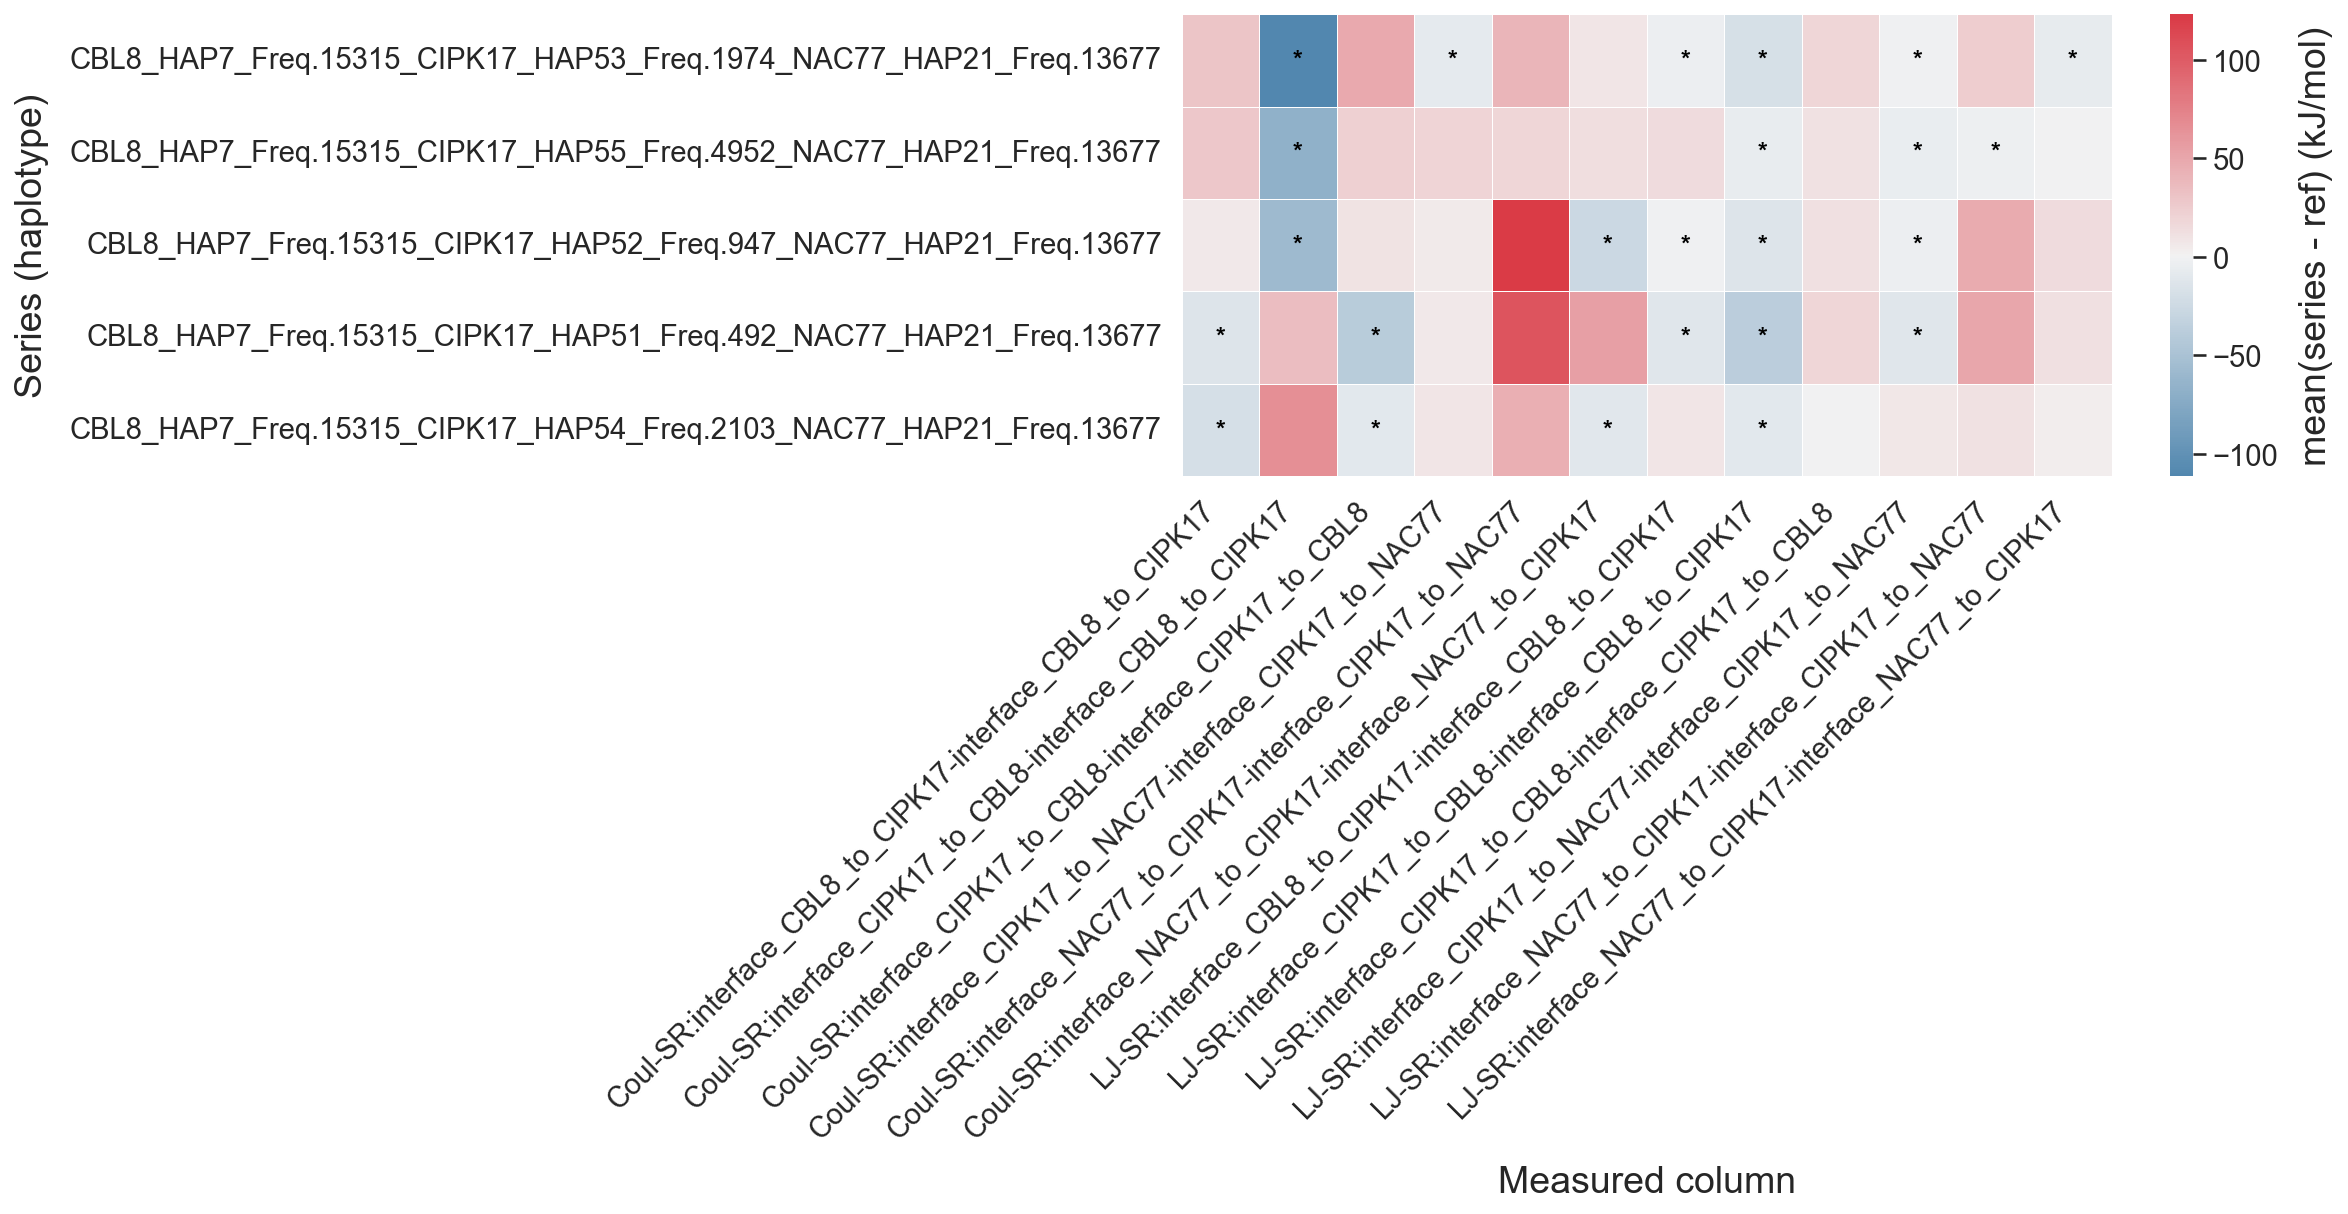

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/1637680485.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


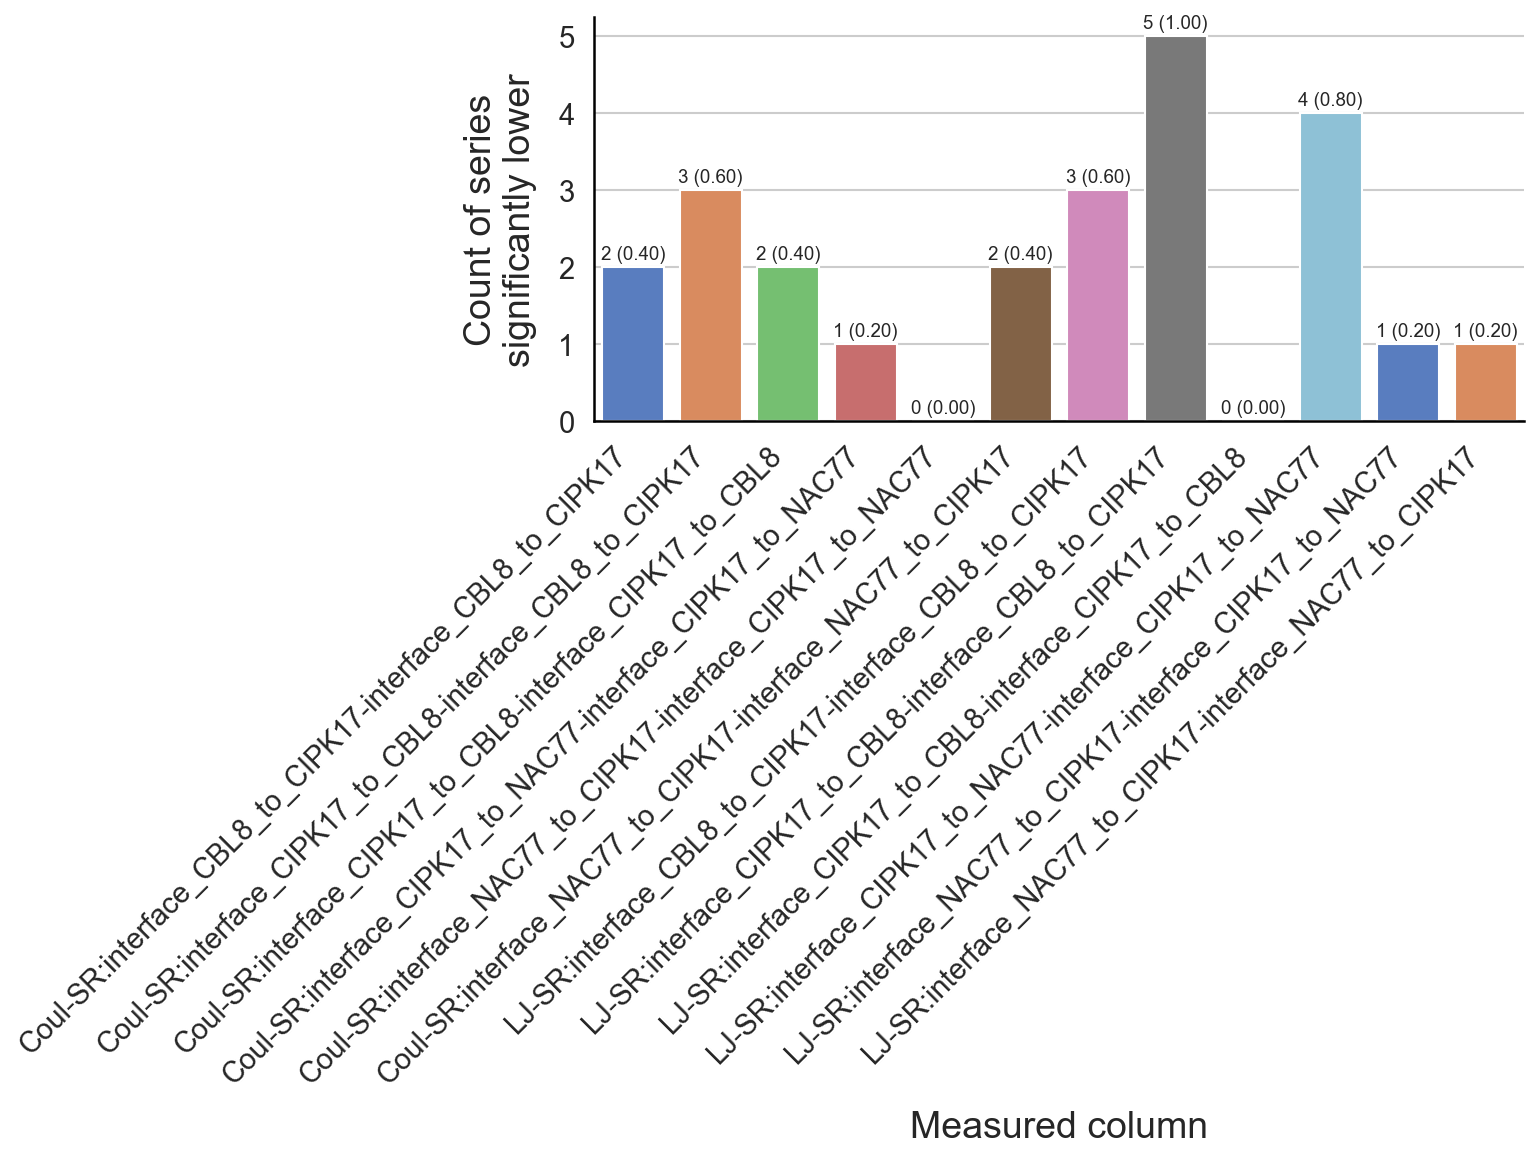

Saved: ../data/interim/results_statistics/summary_heatmap_mean_diff_with_significance_hap7_14mM_NaCl.svg
       ../data/interim/results_statistics/summary_counts_lower_than_ref_hap7_14mM_NaCl.svg


In [91]:
# requires res_df from previous cell
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# pivot mean differences and significance mask
pivot_mean = res_df.pivot(index='series_key', columns='column', values='mean_diff_series_minus_ref')
pivot_sig = res_df.pivot(index='series_key', columns='column', values='lower_by_both').fillna(False)

# sort rows for nicer display (optional: by sum of negative diffs)
row_order = (pivot_mean.fillna(0).min(axis=1)).sort_values().index
pivot_mean = pivot_mean.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]

os.makedirs(out_dir, exist_ok=True)
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_with_significance_hap6.svg") # this is 1M NaCl
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_with_significance_hap7_14mM_NaCl.svg") # this is 14mM NaCl
figpath = os.path.join(out_dir, f"summary_heatmap_mean_diff_with_significance_hap7_{label_suffix}.svg") # this is 5mM Ca2


plt.figure(figsize=(10, max(4, 0.3 * pivot_mean.shape[0])))
cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue <-> red, center=0
ax = sns.heatmap(pivot_mean, cmap=cmap, center=0, annot=False, fmt=".2f",
                 cbar_kws={'label': 'mean(series - ref) (kJ/mol)'}, linewidths=0.3)

# overlay significance stars
for (i, j), val in np.ndenumerate(pivot_sig.values):
    if val:
        ax.text(j + 0.5, i + 0.5, "*", ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax.set_xlabel("Measured column")
ax.set_ylabel("Series (haplotype)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figpath, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Small summary barplot: number (and fraction) of series significantly lower per column
summary = res_df[res_df['lower_by_both']].groupby('column').size().reindex(pivot_mean.columns, fill_value=0)
total_per_col = res_df.groupby('column').size().reindex(pivot_mean.columns, fill_value=0)
frac = summary / total_per_col

fig2, ax2 = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=summary.index, y=summary.values, palette='muted', ax=ax2)
for i, (cnt, f) in enumerate(zip(summary.values, frac.values)):
    ax2.text(i, cnt + 0.05, f"{cnt} ({f:.2f})", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel("Count of series\nsignificantly lower")
ax2.set_xlabel("Measured column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_hap6.svg") # this is 1M NaCl
# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_hap7_14mM_NaCl.svg") # this is 14mM NaCl
outbar = os.path.join(out_dir, f"summary_counts_lower_than_ref_hap7_{label_suffix}.svg") # this is 5mM Ca2

plt.savefig(outbar, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved: {figpath}\n       {outbar}")

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/3610621671.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


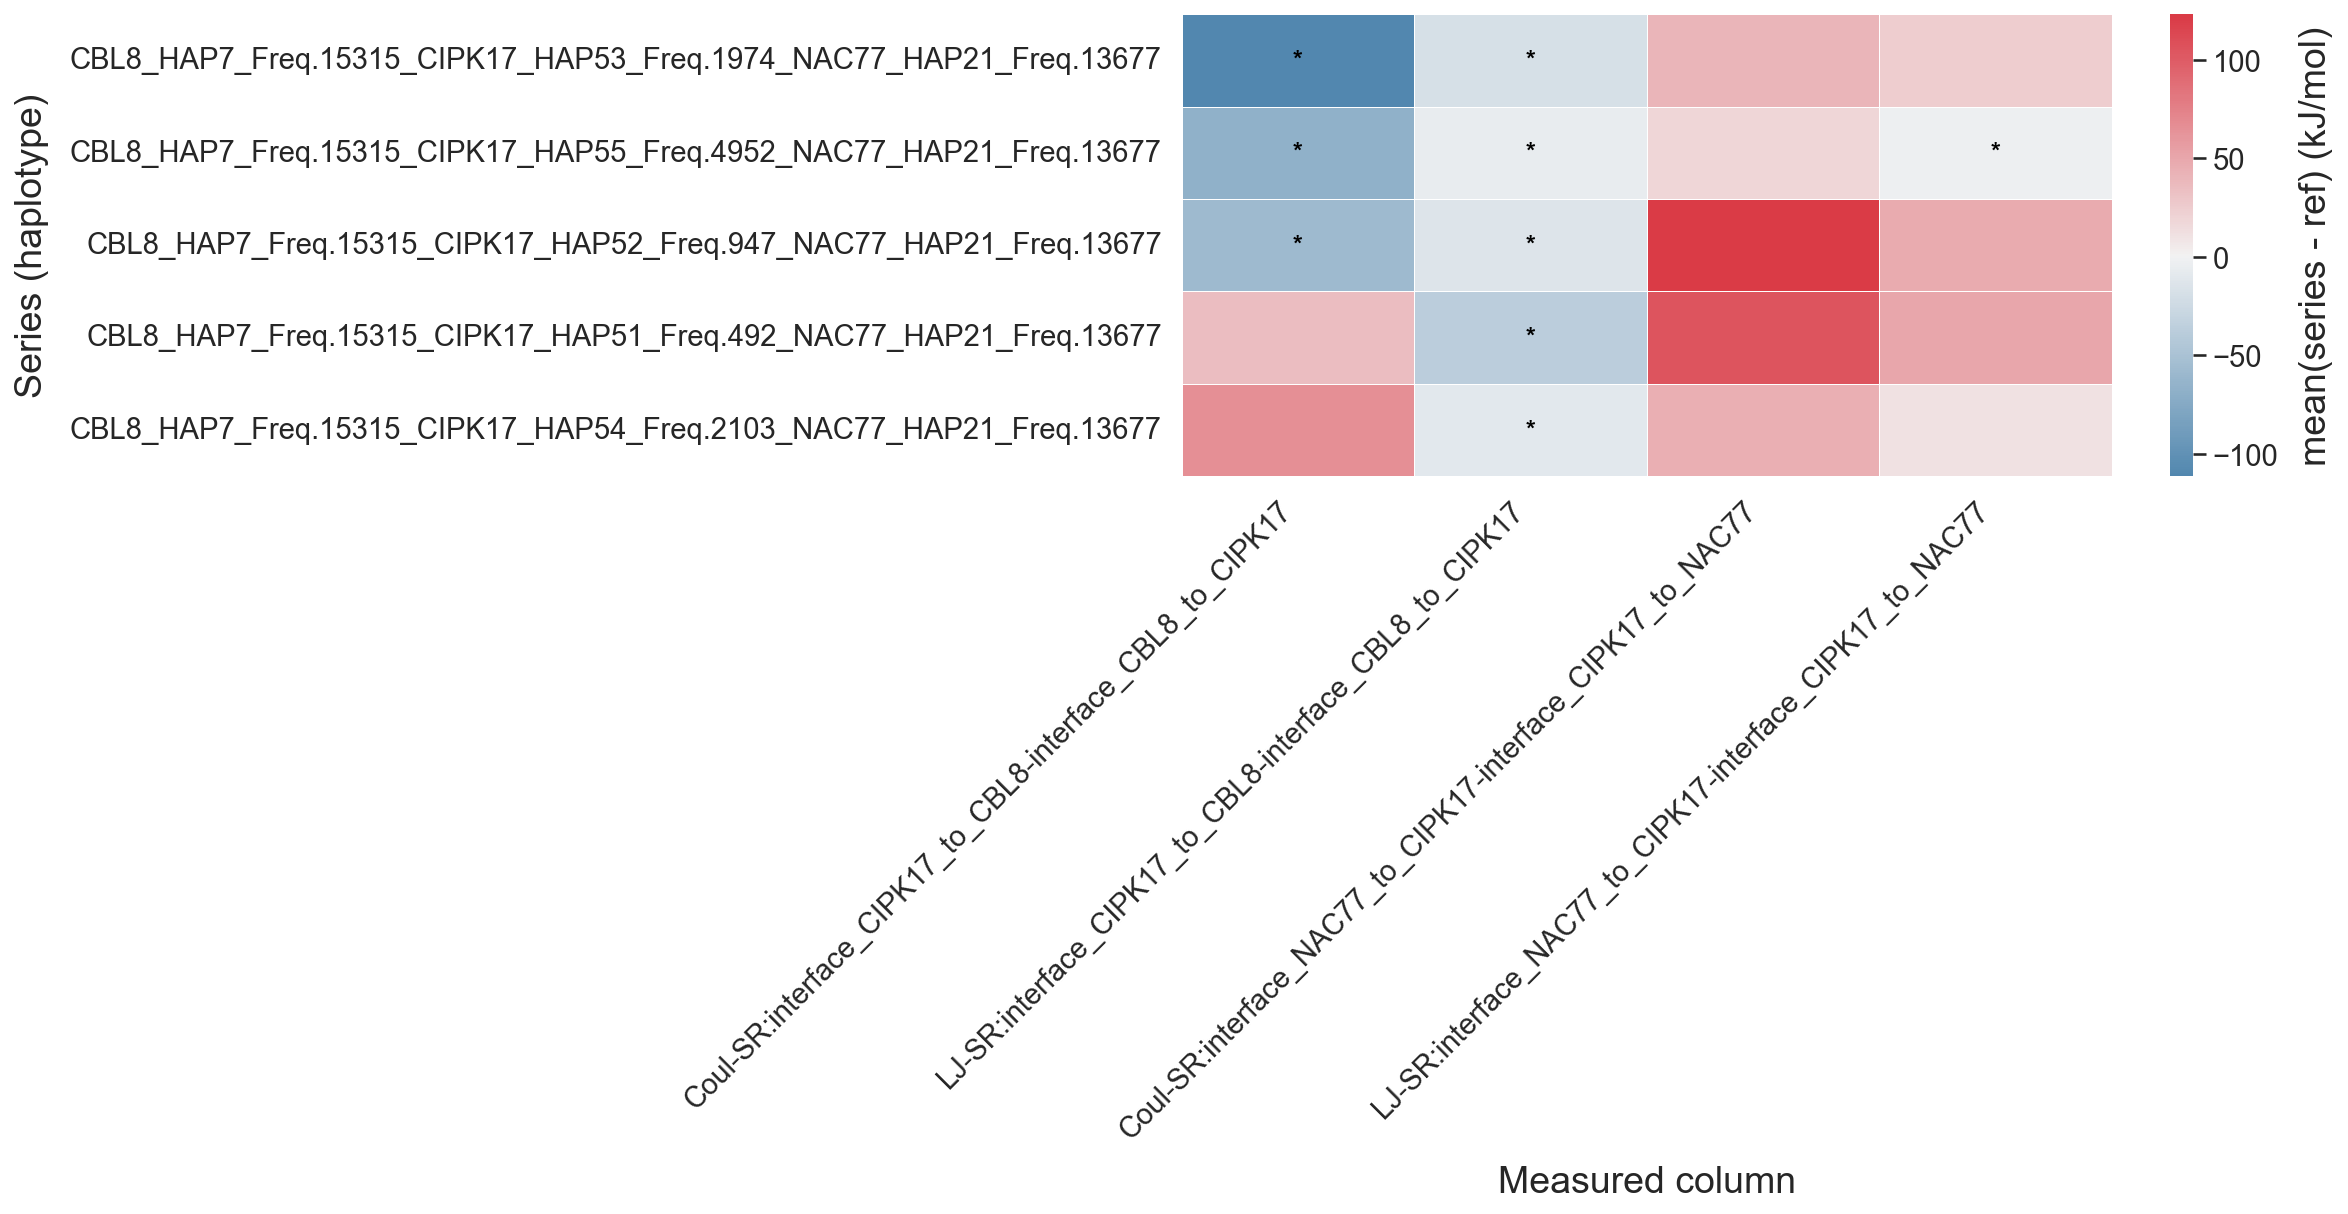

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_23672/3610621671.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


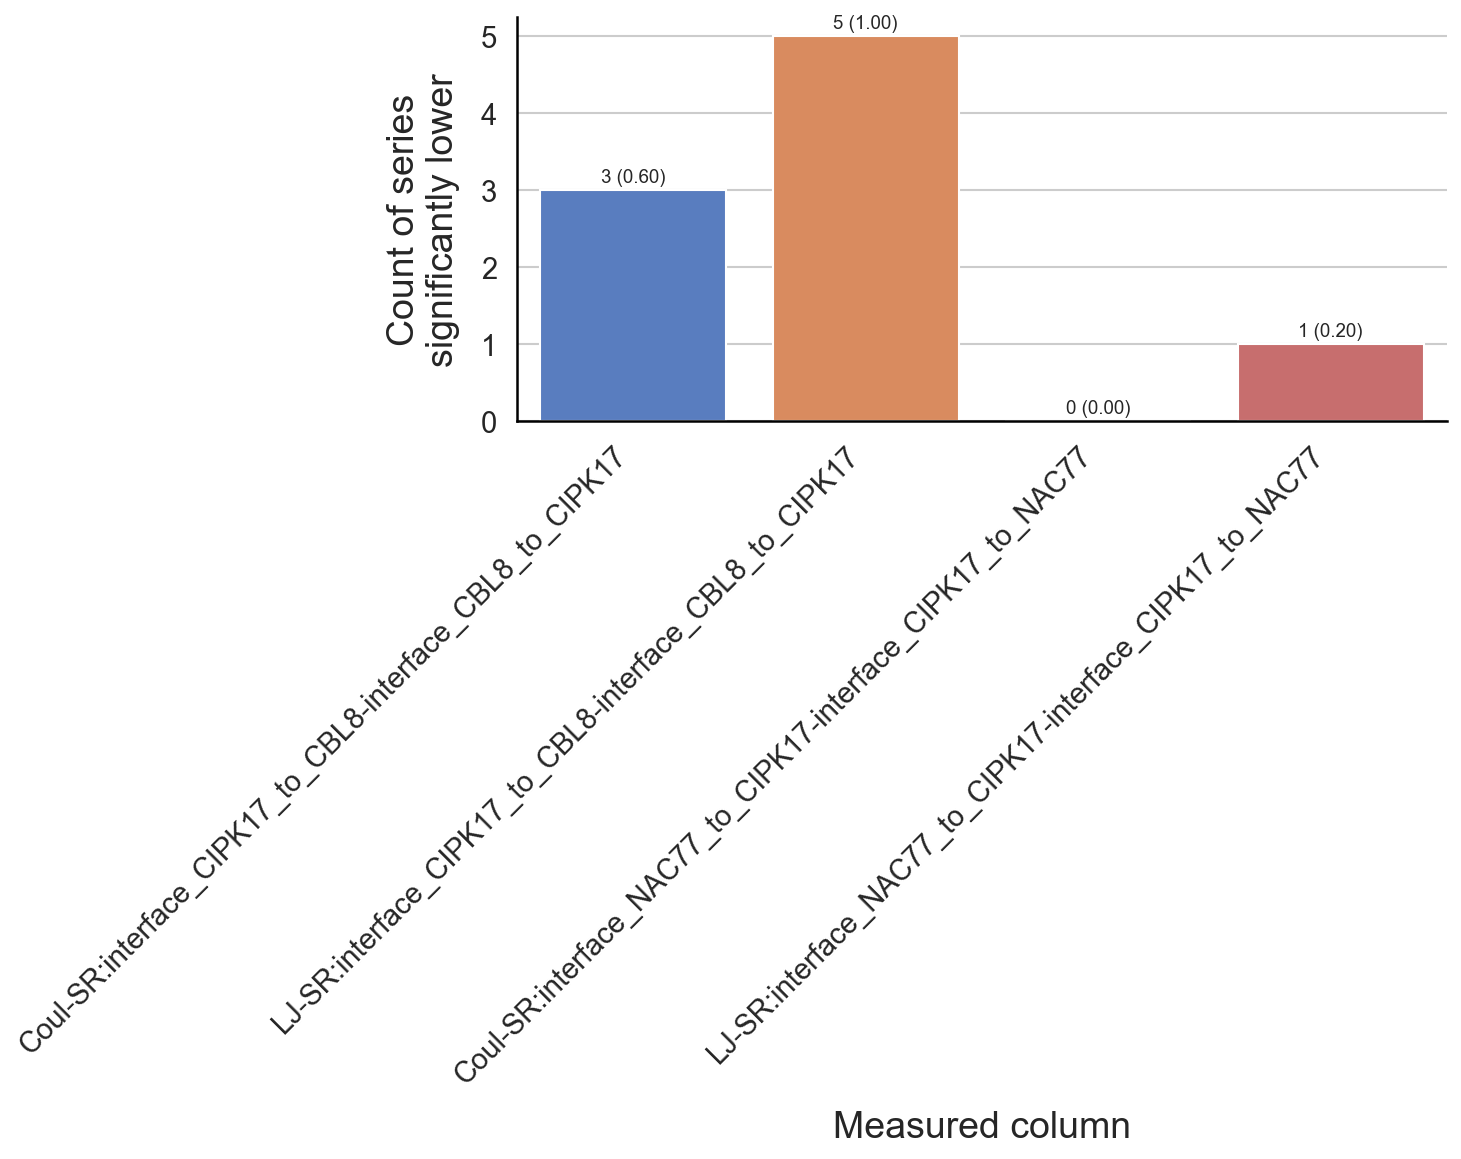

Saved: ../data/interim/results_statistics/summary_heatmap_mean_diff_interfaces_filtered_hap7_14mM_NaCl.svg
       ../data/interim/results_statistics/summary_counts_lower_than_ref_interfaces_filtered_hap7_14mM_NaCl.svg


In [92]:
if 'res_df' not in globals():
    raise RuntimeError("res_df not found — run the statistics cell first.")

# only plot these four interface labels (order preserved)
ALLOWED = [
    "Coul-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17",
    "LJ-SR:interface_CIPK17_to_CBL8-interface_CBL8_to_CIPK17",
    "Coul-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77",
    "LJ-SR:interface_NAC77_to_CIPK17-interface_CIPK17_to_NAC77",
]

present = [c for c in ALLOWED if c in set(res_df['column'])]
if not present:
    print("None of the requested interface columns found in res_df['column'].")
    print("Available columns:", sorted(set(res_df['column'])))
    raise RuntimeError("No matching interface columns to plot.")

# filter to only the allowed interface rows
res_sub = res_df[res_df['column'].isin(present)].copy()

# pivot mean differences and significance mask (only selected columns)
pivot_mean = res_sub.pivot(index='series_key', columns='column', values='mean_diff_series_minus_ref')
pivot_sig = res_sub.pivot(index='series_key', columns='column', values='lower_by_both').fillna(False)

# ensure columns appear in requested order
pivot_mean = pivot_mean.reindex(columns=present)
pivot_sig = pivot_sig.reindex(columns=present)

# sort rows for nicer display (optional: by most negative value)
row_order = (pivot_mean.fillna(0).min(axis=1)).sort_values().index
pivot_mean = pivot_mean.loc[row_order]
pivot_sig = pivot_sig.loc[row_order]

os.makedirs(out_dir, exist_ok=True)
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_interfaces_filtered_hap6.svg") # this is 1M NaCl
# figpath = os.path.join(out_dir, "summary_heatmap_mean_diff_interfaces_filtered_hap7_14mM_NaCl.svg") # this is 14mM NaCl
figpath = os.path.join(out_dir, f"summary_heatmap_mean_diff_interfaces_filtered_hap7_{label_suffix}.svg") # this is 5mM Ca2


plt.figure(figsize=(10, max(4, 0.5 * pivot_mean.shape[0])))
cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue <-> red, center=0
ax = sns.heatmap(pivot_mean, cmap=cmap, center=0, annot=False, fmt=".2f",
                 cbar_kws={'label': 'mean(series - ref) (kJ/mol)'}, linewidths=0.3)

# overlay significance stars
for (i, j), val in np.ndenumerate(pivot_sig.values):
    if val:
        ax.text(j + 0.5, i + 0.5, "*", ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax.set_xlabel("Measured column")
ax.set_ylabel("Series (haplotype)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figpath, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Small summary barplot: number (and fraction) of series significantly lower per selected column
summary = res_sub[res_sub['lower_by_both']].groupby('column').size().reindex(present, fill_value=0)
total_per_col = res_sub.groupby('column').size().reindex(present, fill_value=0)
frac = summary / total_per_col.replace(0, np.nan)

# outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_interfaces_filtered_hap6.svg")
outbar = os.path.join(out_dir, "summary_counts_lower_than_ref_interfaces_filtered_hap7_14mM_NaCl.svg") # this is 14mM NaCl
outbar = os.path.join(out_dir, f"summary_counts_lower_than_ref_interfaces_filtered_hap7_{label_suffix}.svg") # this is 5mM Ca2


fig2, ax2 = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=summary.index, y=summary.values, palette='muted', ax=ax2)
for i, (cnt, f) in enumerate(zip(summary.values, frac.values)):
    ax2.text(i, cnt + 0.05, f"{cnt} ({0.0 if np.isnan(f) else f:.2f})", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel("Count of series\nsignificantly lower")
ax2.set_xlabel("Measured column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(outbar, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved: {figpath}\n       {outbar}")